In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NYC_Data.csv to NYC_Data.csv
Saving LA_Data.csv to LA_Data.csv


In [ ]:
import pandas as pd
import numpy as np

la_df = pd.read_csv("LA_Data.csv")
nyc_df = pd.read_csv("NYC_Data.csv")

def prepare_city_data(city_df, city_name):
    """
    Prepare data for a single city with correct pollutant names
    """
    df_clean = city_df.copy()

    # Convert to datetime
    df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
    df_clean = df_clean.dropna(subset=['Date'])

    df_clean = df_clean.sort_values('Date').reset_index(drop=True)

    # Extract time features
    df_clean['year'] = df_clean['Date'].dt.year
    df_clean['month'] = df_clean['Date'].dt.month
    df_clean['day_of_week'] = df_clean['Date'].dt.dayofweek
    df_clean['day_of_year'] = df_clean['Date'].dt.dayofyear

    # City identifier
    df_clean['city'] = city_name

    return df_clean

# Prepare each city separately
la_clean = prepare_city_data(la_df, 'LA')
nyc_clean = prepare_city_data(nyc_df, 'NYC')

print("LA data shape:", la_clean.shape)
print("NYC data shape:", nyc_clean.shape)
print("LA Pollutants:", la_clean['Pollutant'].unique())
print("NYC Pollutants:", nyc_clean['Pollutant'].unique())

LA data shape: (12070, 25)
NYC data shape: (14697, 25)
LA Pollutants: ['Carbon monoxide' 'Ozone' 'NO2' 'PM2.5']
NYC Pollutants: ['Carbon monoxide' 'Ozone' 'PM2.5' 'NO2']


#Feature Engineering

In [ ]:
def create_features(df, target='Daily AQI Value', lags=7):
    """
    Create time series features including lagged values
    """
    df_feat = df.copy()

    # Create lag features
    for lag in range(1, lags + 1):
        df_feat[f'lag_{lag}'] = df_feat[target].shift(lag)

    # Rolling statistics
    df_feat['rolling_mean_7'] = df_feat[target].rolling(window=7).mean()
    df_feat['rolling_std_7'] = df_feat[target].rolling(window=7).std()

    return df_feat

# Process each city and pollutant separately
city_data = {}

POLLUTANTS = ['Carbon monoxide', 'NO2', 'Ozone', 'PM2.5']

for city_name, city_df in [('LA', la_clean), ('NYC', nyc_clean)]:
    city_data[city_name] = {}

    for poll in POLLUTANTS:
        # Filter for this pollutant
        poll_df = city_df[city_df['Pollutant'] == poll].copy()

        if len(poll_df) > 50:
            poll_feat = create_features(poll_df, target='Daily AQI Value')
            poll_feat = poll_feat.dropna()  # Remove rows with NaN

            # Select only numeric columns for scaling and LSTM
            numeric_cols = poll_feat.select_dtypes(include=np.number).columns.tolist()
            poll_feat_numeric = poll_feat[numeric_cols]

            city_data[city_name][poll] = poll_feat_numeric
            print(f"{city_name} - {poll}: {len(poll_feat_numeric)} samples")
        else:
            print(f"{city_name} - {poll}: Not enough data ({len(poll_df)} samples)")

LA - Carbon monoxide: 3655 samples
LA - NO2: 0 samples
LA - Ozone: 0 samples
LA - PM2.5: 0 samples
NYC - Carbon monoxide: 3789 samples
NYC - NO2: 0 samples
NYC - Ozone: 0 samples
NYC - PM2.5: 0 samples


In [ ]:
city_data_simple = {}

for city_name, city_df in [('LA', la_clean), ('NYC', nyc_clean)]:
    city_data_simple[city_name] = {}
    print(f"\nProcessing {city_name}:")

    for poll in POLLUTANTS:
        poll_df = city_df[city_df['Pollutant'] == poll].copy()

        if len(poll_df) > 50:
            # Use basic features without lag
            features_df = poll_df[['year', 'month', 'day_of_week', 'day_of_year', 'Daily AQI Value']].copy()
            features_df = features_df.dropna()

            city_data_simple[city_name][poll] = features_df
            print(f"  {poll}: {len(features_df)} samples")
        else:
            print(f"  {poll}: Not enough data ({len(poll_df)} samples)")

city_data = city_data_simple


Processing LA:
  Carbon monoxide: 3663 samples
  NO2: 3616 samples
  Ozone: 3605 samples
  PM2.5: 1186 samples

Processing NYC:
  Carbon monoxide: 3796 samples
  NO2: 3541 samples
  Ozone: 3741 samples
  PM2.5: 3619 samples


#LSTM

Training LSTM for LA - Carbon monoxide


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


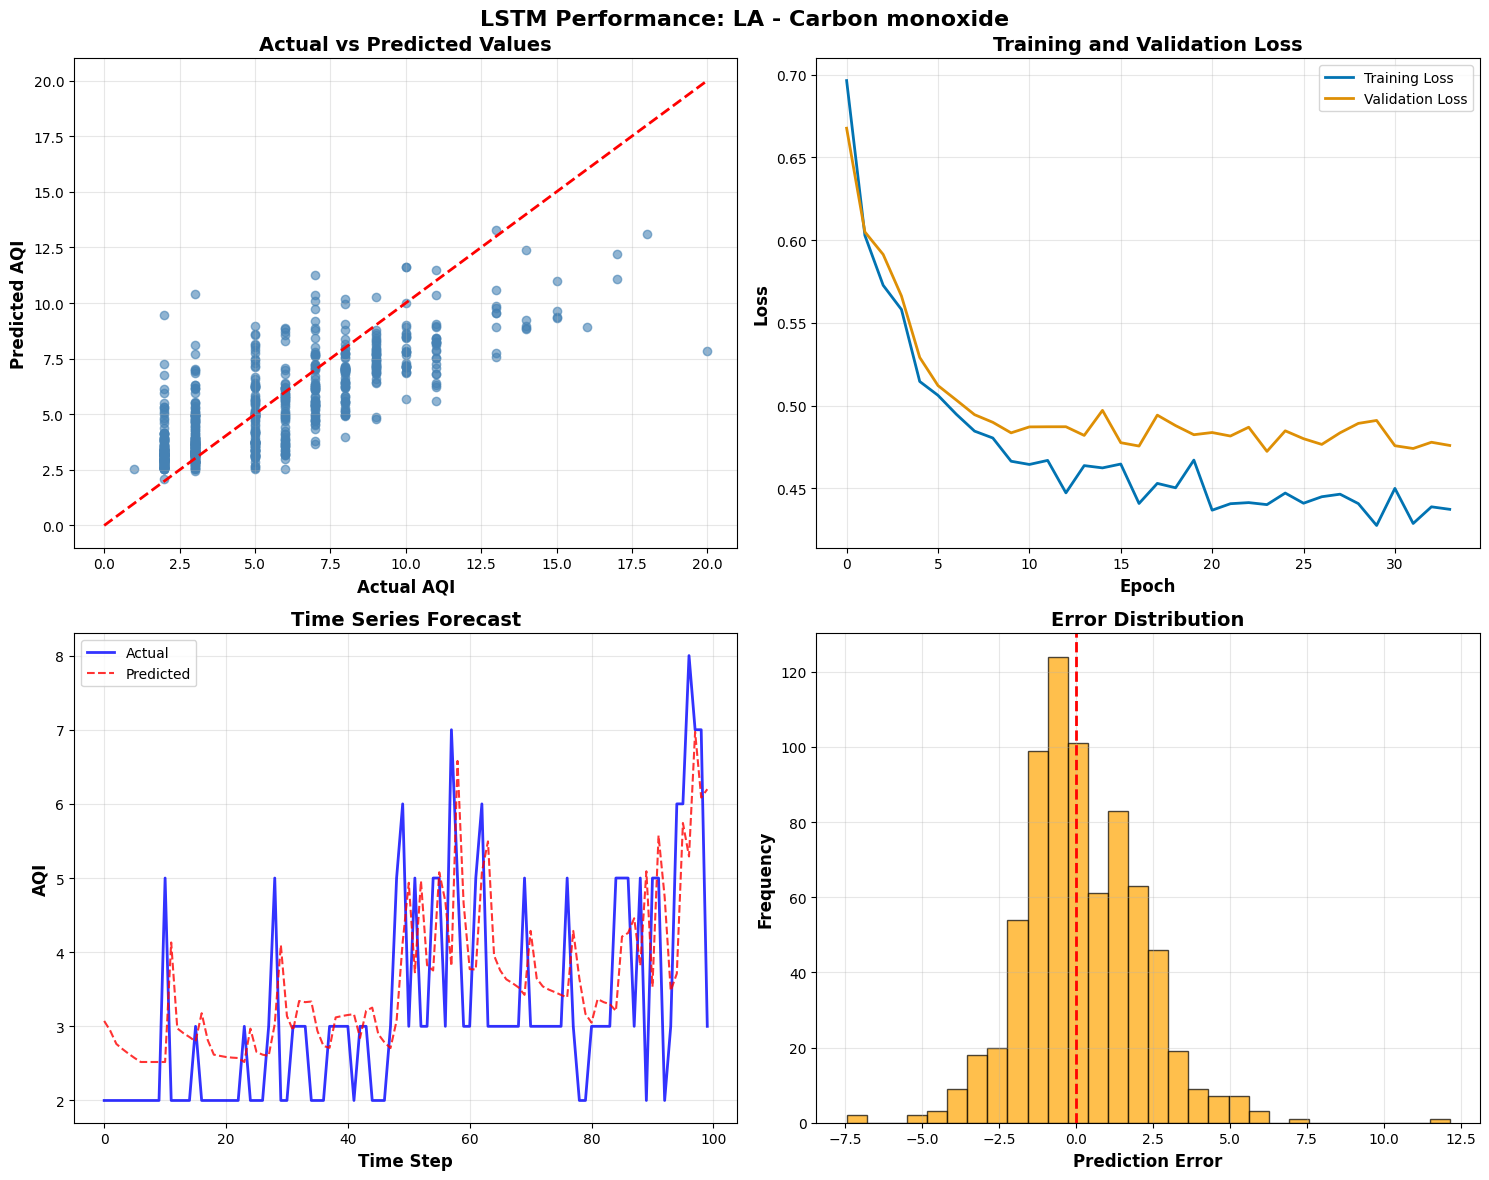

Training LSTM for LA - Ozone


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


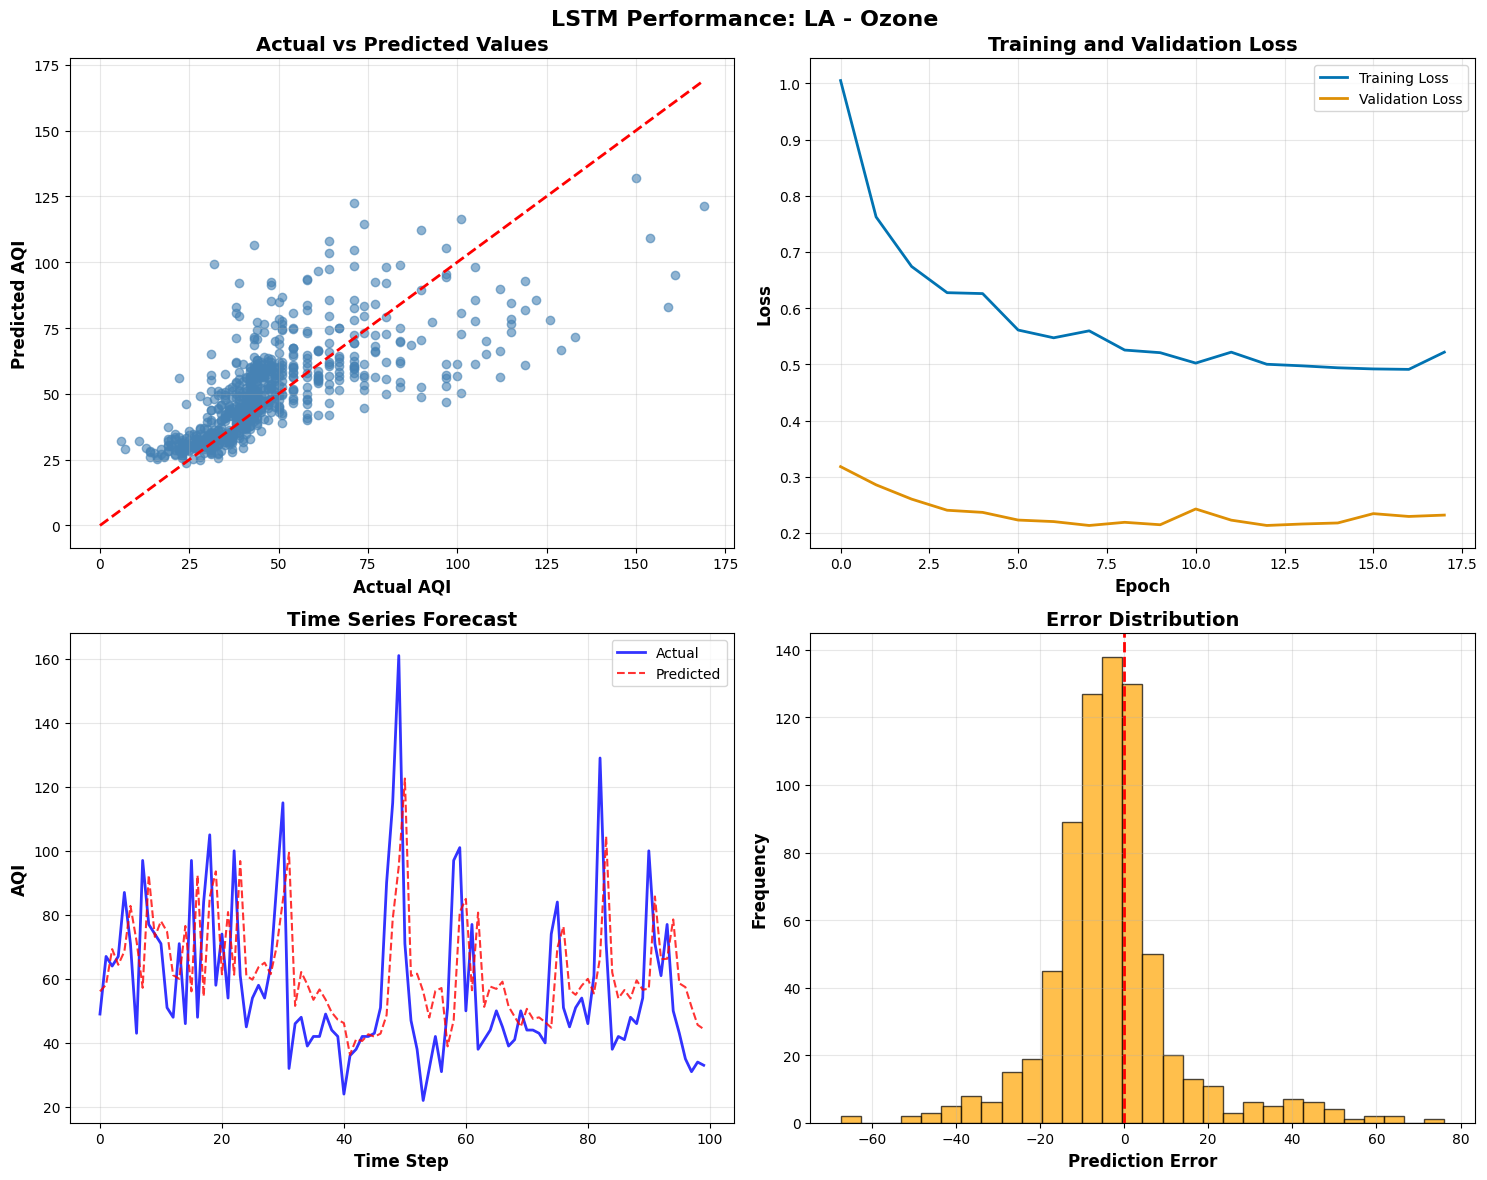

Training LSTM for LA - NO2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


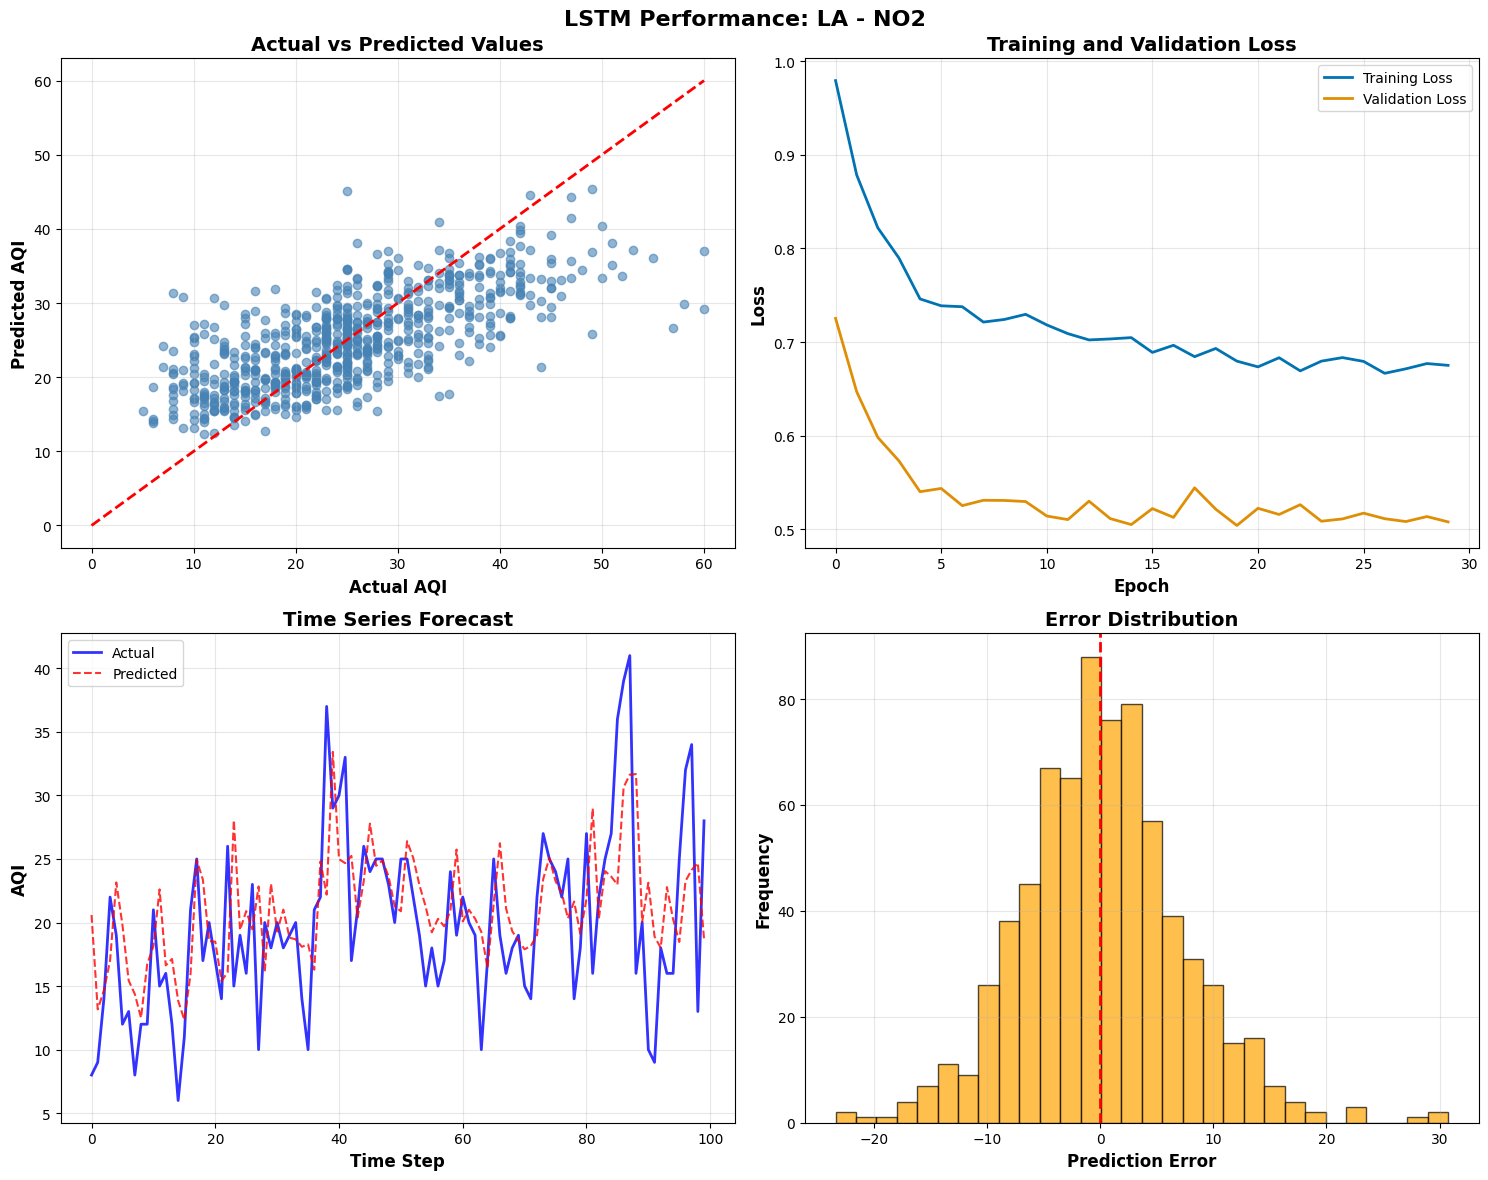

Training LSTM for LA - PM2.5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


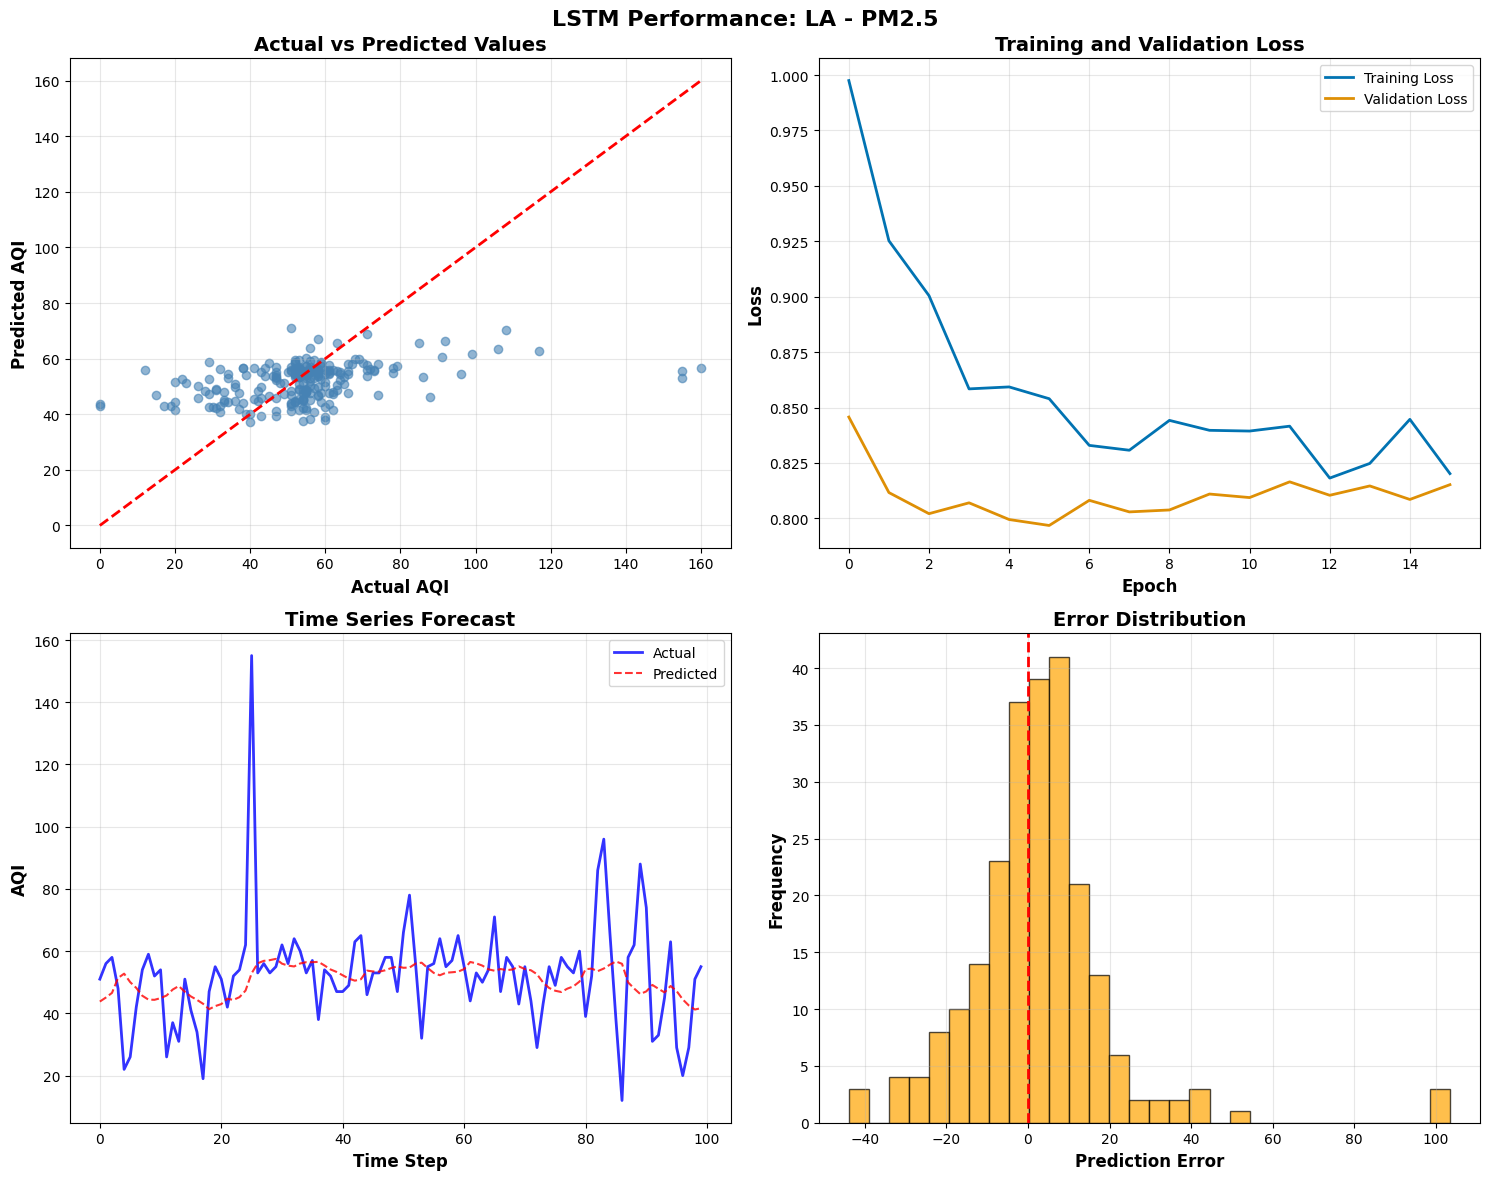

Training LSTM for NYC - Carbon monoxide


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


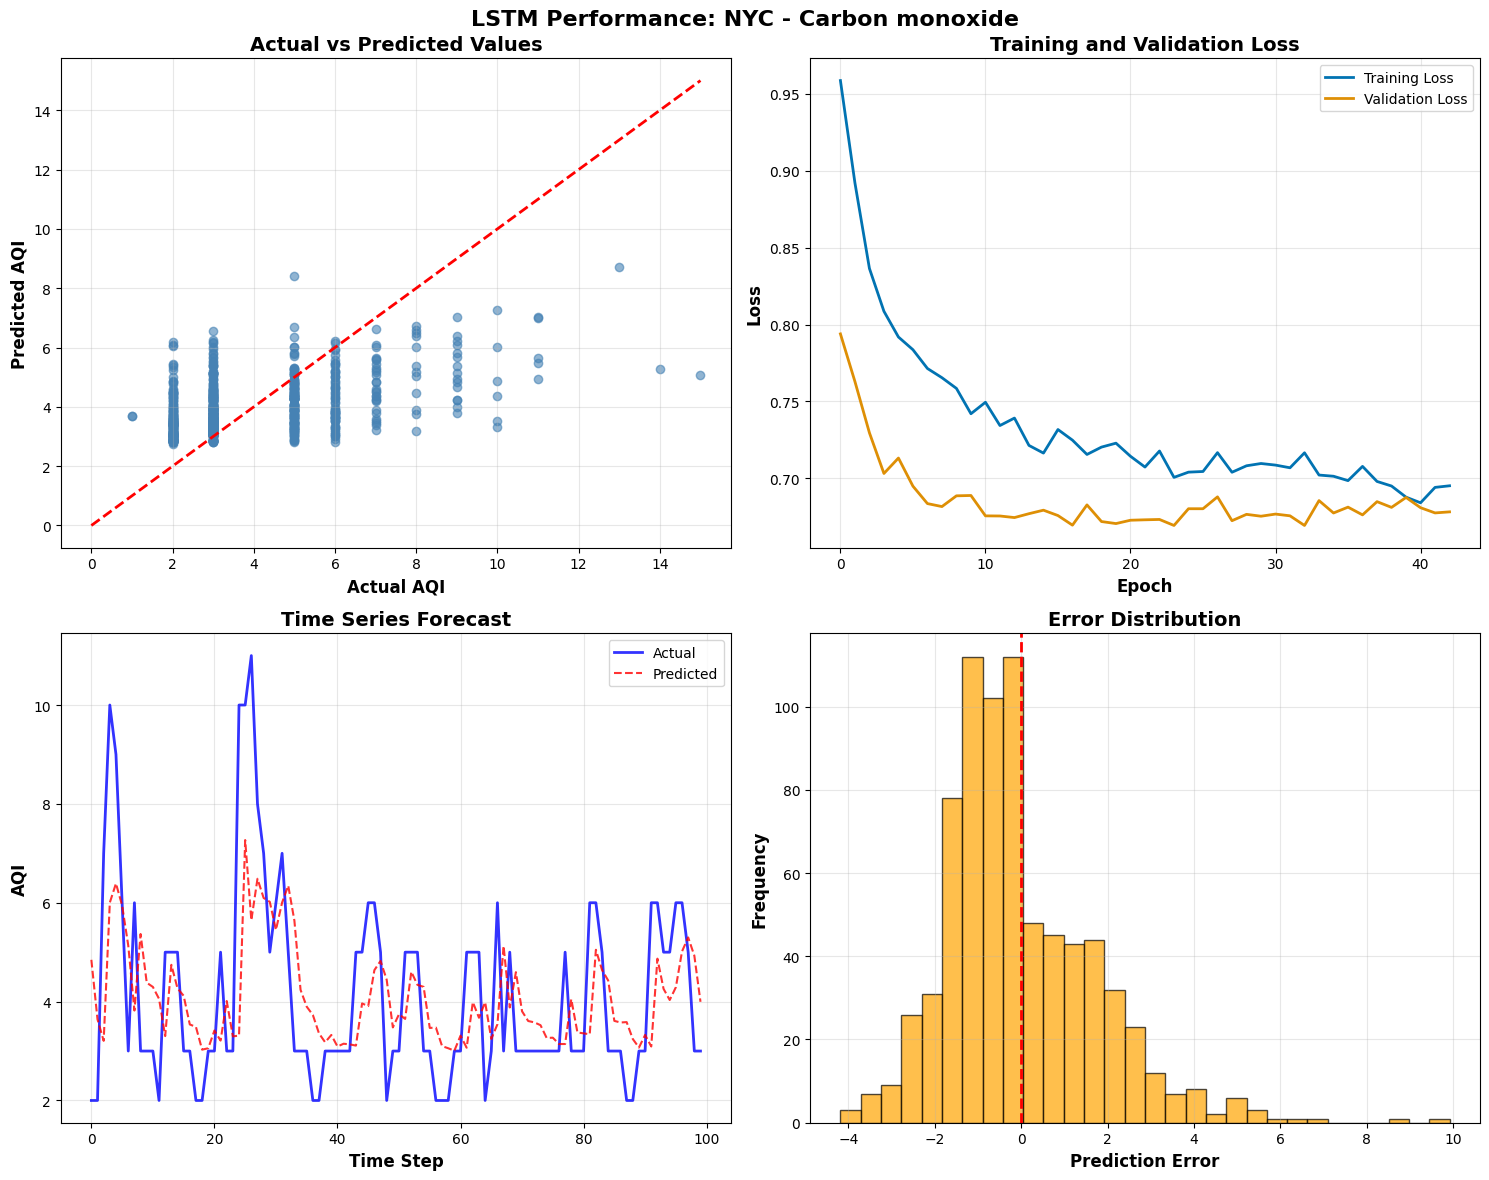

Training LSTM for NYC - Ozone


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


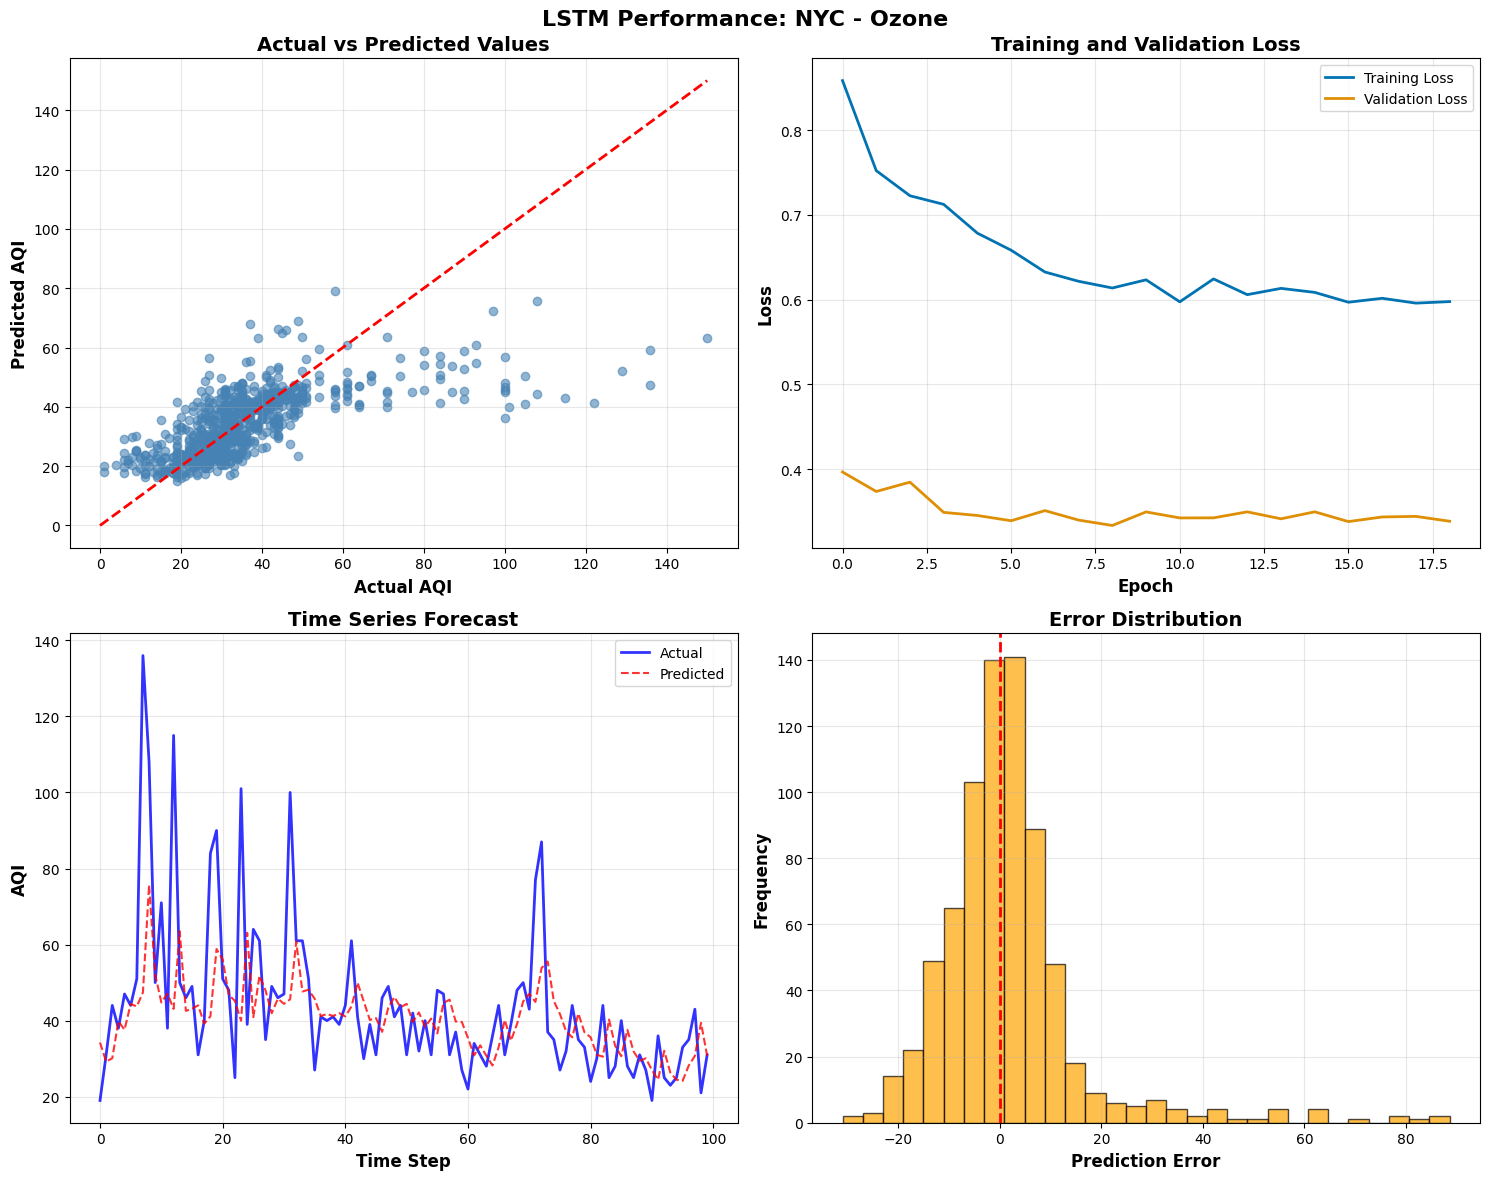

Training LSTM for NYC - NO2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


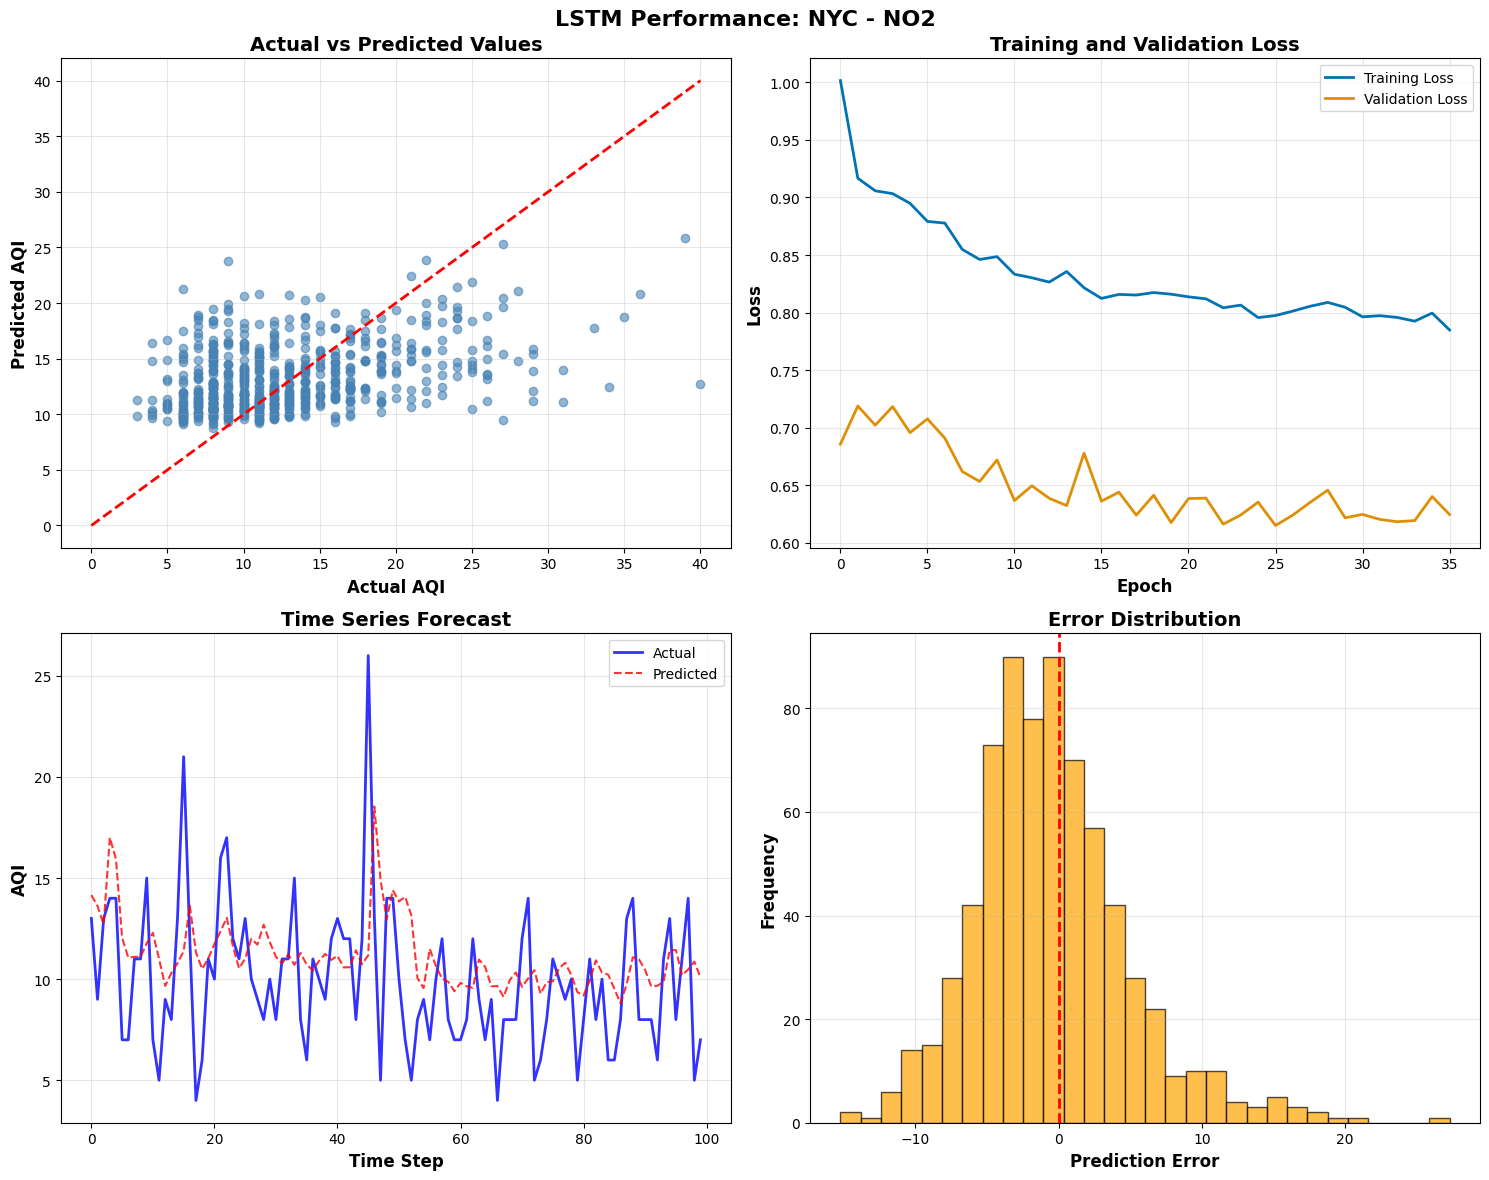

Training LSTM for NYC - PM2.5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


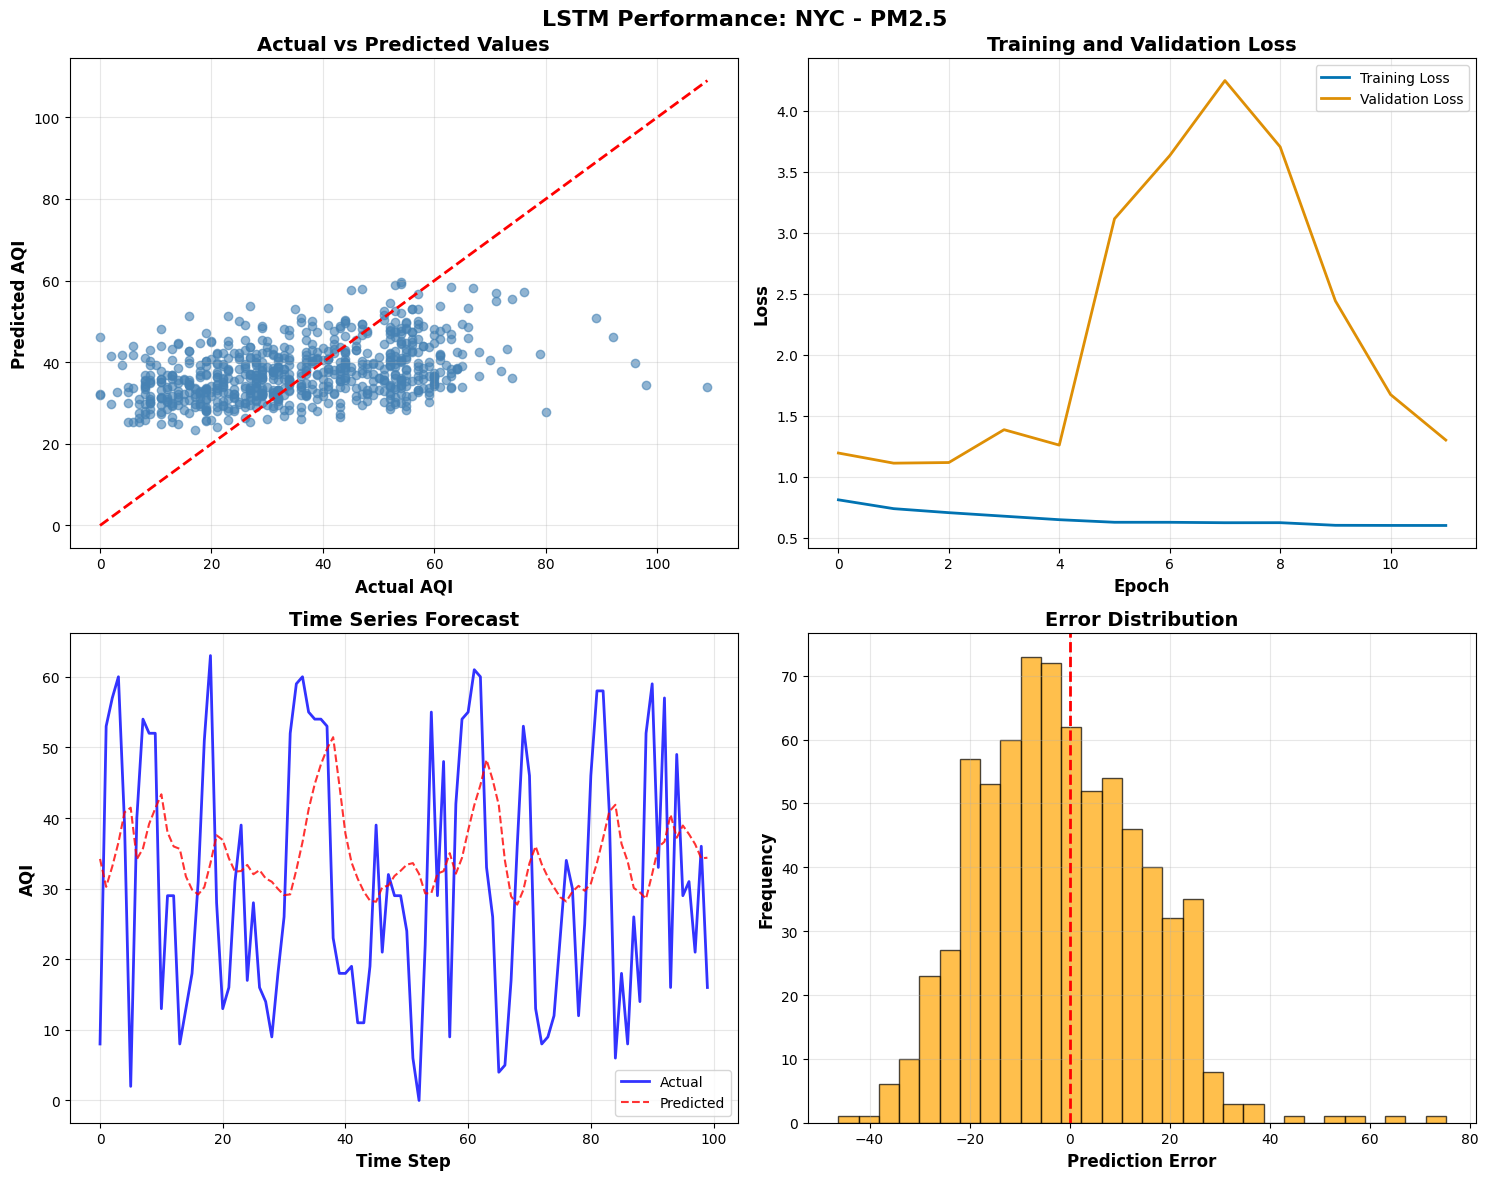

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

plt.style.use('default')
sns.set_palette("colorblind")

# ------------------------
# LSTM Model Architecture
# ------------------------
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape, activation='relu'),
        Dropout(0.3),
        LSTM(32, return_sequences=False, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


# ------------------------
# Prepare data for LSTM
# ------------------------
def prepare_lstm_data(series, time_steps=7):
    """Prepare 3D data for LSTM [samples, time_steps, features]"""
    X, y = [], []
    for i in range(len(series) - time_steps):
        X.append(series[i:(i + time_steps)])
        y.append(series[i + time_steps])
    return np.array(X), np.array(y)


# ------------------------
# Train LSTM per pollutant
# ------------------------
def train_lstm_for_pollutant(city_data, city_name, pollutant, time_steps=7):
    """Train an LSTM for one city & pollutant using AQI time series"""
    print(f"Training LSTM for {city_name} - {pollutant}")

    if "Daily AQI Value" not in city_data[city_name][pollutant].columns:
        print(f"No 'Daily AQI Value' found for {city_name} - {pollutant}")
        return None, None

    series = city_data[city_name][pollutant]["Daily AQI Value"].values.reshape(-1, 1)

    if len(series) < time_steps + 1:
        print(f"Not enough rows for {city_name} - {pollutant} to create time steps ({len(series)} rows).")
        return None, None

    # Scale the series
    scaler = StandardScaler()
    series_scaled = scaler.fit_transform(series)

    # Prepare LSTM data
    X_lstm, y_lstm = prepare_lstm_data(series_scaled, time_steps)

    # Split train/test (80/20)
    split_idx = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:split_idx], X_lstm[split_idx:]
    y_train_lstm, y_test_lstm = y_lstm[:split_idx], y_lstm[split_idx:]

    # Train model
    model = create_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
    history = model.fit(
        X_train_lstm, y_train_lstm,
        epochs=100, batch_size=32, validation_split=0.2,
        verbose=0, callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
    )

    # Predict
    y_pred_scaled = model.predict(X_test_lstm)

    # Inverse transform predictions and actual values
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    y_test = scaler.inverse_transform(y_test_lstm).flatten()


    # Metrics
    metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    }

    # ------------------------
    # Visualization
    # ------------------------
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'LSTM Performance: {city_name} - {pollutant}', fontsize=16, fontweight='bold')

    # 1. Actual vs Predicted
    axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')
    max_val = max(y_test.max(), y_pred.max())
    axes[0,0].plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    axes[0,0].set_xlabel('Actual AQI', fontweight='bold', fontsize=12)
    axes[0,0].set_ylabel('Predicted AQI', fontweight='bold', fontsize=12)
    axes[0,0].set_title('Actual vs Predicted Values', fontweight='bold', fontsize=14)
    axes[0,0].grid(True, alpha=0.3)

    # 2. Training history
    axes[0,1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0,1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0,1].set_xlabel('Epoch', fontweight='bold', fontsize=12)
    axes[0,1].set_ylabel('Loss', fontweight='bold', fontsize=12)
    axes[0,1].set_title('Training and Validation Loss', fontweight='bold', fontsize=14)
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # 3. Time series comparison
    n_points = min(100, len(y_test))
    time_range = range(n_points)
    axes[1,0].plot(time_range, y_test[:n_points], 'b-', label='Actual', linewidth=2, alpha=0.8)
    axes[1,0].plot(time_range, y_pred[:n_points], 'r--', label='Predicted', linewidth=1.5, alpha=0.8)
    axes[1,0].set_xlabel('Time Step', fontweight='bold', fontsize=12)
    axes[1,0].set_ylabel('AQI', fontweight='bold', fontsize=12)
    axes[1,0].set_title('Time Series Forecast', fontweight='bold', fontsize=14)
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # 4. Error distribution
    errors = y_test - y_pred
    axes[1,1].hist(errors, bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1,1].set_xlabel('Prediction Error', fontweight='bold', fontsize=12)
    axes[1,1].set_ylabel('Frequency', fontweight='bold', fontsize=12)
    axes[1,1].set_title('Error Distribution', fontweight='bold', fontsize=14)
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'LSTM_{city_name}_{pollutant.replace(" ", "_")}_Performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    return metrics, model


# ------------------------
# Run for all cities & pollutants
# ------------------------
lstm_results = {}
for city in ["LA", "NYC"]:
    if city in city_data:
        lstm_results[city] = {}
        for poll in POLLUTANTS:
            if poll in city_data[city] and len(city_data[city][poll]) > 50:
                 metrics, model = train_lstm_for_pollutant(city_data, city, poll)
                 if metrics is not None:
                    lstm_results[city][poll] = metrics
            else:
                print(f"Skipping {city} - {poll}: Not enough data for training.")

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4ebba8373fb1258cc1fe29b31f76a9bf9c34e81a4a64b358e1594b6be07277d5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


#XGBOOST with SHAP-LIME analysis


In [ ]:
import xgboost as xgb
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_xgboost_for_pollutant(city_data, city_name, pollutant):
    """Train XGBoost for specific city and pollutant with SHAP & LIME analysis"""
    print(f"Training XGBoost for {city_name} - {pollutant}")

    # Filter data
    data = city_data[city_name][pollutant].copy()
    X = data.drop(['Daily AQI Value', 'Date', 'city', 'Pollutant'], axis=1, errors='ignore')
    y = data['Daily AQI Value']

    # Store feature names for SHAP & LIME
    feature_names = X.columns.tolist()

    # Split (80/20)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Convert to numpy arrays for LIME
    X_train_np = X_train.values
    X_test_np = X_test.values

    # Train model
    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    metrics = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    }

    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'XGBoost Performance: {city_name} - {pollutant}', fontsize=16, fontweight='bold')

    # 1. Actual vs Predicted
    axes[0].scatter(y_test, y_pred, alpha=0.6, color='green')
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    axes[0].set_xlabel('Actual AQI', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Predicted AQI', fontweight='bold', fontsize=12)
    axes[0].set_title('Actual vs Predicted Values', fontweight='bold', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.05, 0.95, f'R² = {metrics["R²"]:.3f}\nMAE = {metrics["MAE"]:.2f}',
                transform=axes[0].transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.8))

    # 2. Feature Importance
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    axes[1].barh(range(len(feature_importance)), feature_importance['importance'])
    axes[1].set_yticks(range(len(feature_importance)))
    axes[1].set_yticklabels(feature_importance['feature'])
    axes[1].set_xlabel('Importance', fontweight='bold', fontsize=12)
    axes[1].set_title('Top 10 Feature Importance', fontweight='bold', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    # 3. Error distribution
    errors = y_test - y_pred
    axes[2].hist(errors, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[2].set_xlabel('Prediction Error', fontweight='bold', fontsize=12)
    axes[2].set_ylabel('Frequency', fontweight='bold', fontsize=12)
    axes[2].set_title('Error Distribution', fontweight='bold', fontsize=14)
    axes[2].grid(True, alpha=0.3)
    axes[2].text(0.05, 0.95, f'Mean Error: {errors.mean():.2f}\nStd Error: {errors.std():.2f}',
                transform=axes[2].transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'XGBoost_{city_name}_{pollutant.replace(" ", "_")}_Performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ===========================================
    # SHAP ANALYSIS
    # ===========================================
    print(f"🔍 Running SHAP analysis for {city_name} - {pollutant}...")

    try:
        # Create SHAP explainer
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)

        # 1. SHAP Summary Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
        plt.title(f'SHAP Feature Importance: {city_name} - {pollutant}',
                 fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'SHAP_Summary_{city_name}_{pollutant.replace(" ", "_")}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

        # 2. SHAP Bar Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                         plot_type="bar", show=False)
        plt.title(f'SHAP Feature Importance (Ranked): {city_name} - {pollutant}',
                 fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'SHAP_Bar_{city_name}_{pollutant.replace(" ", "_")}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

        print(f"✅ SHAP analysis completed for {city_name} - {pollutant}")

    except Exception as e:
        print(f"❌ SHAP analysis failed: {e}")

    # ===========================================
    # LIME ANALYSIS
    # ===========================================
    print(f"🔍 Running LIME analysis for {city_name} - {pollutant}...")

    try:
        # Create LIME explainer
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_train_np,
            feature_names=feature_names,
            mode='regression',
            verbose=False,
            random_state=42
        )

        # Explain 3 representative instances
        instances_to_explain = [
            np.argmax(y_test),  # Highest AQI day
            np.argmin(y_test),  # Lowest AQI day
            len(y_test) // 2    # Middle instance
        ]

        for i, instance_idx in enumerate(instances_to_explain[:3]):  # Limit to 3
            # Explain this instance
            exp = explainer.explain_instance(
                data_row=X_test_np[instance_idx],
                predict_fn=model.predict,
                num_features=10
            )

            # Create LIME plot
            plt.figure(figsize=(12, 8))
            exp.as_pyplot_figure()
            plt.title(f'LIME Explanation: {city_name} - {pollutant}\nInstance {i+1} (True AQI: {y_test.iloc[instance_idx]:.1f})',
                     fontsize=16, fontweight='bold', pad=20)
            plt.tight_layout()
            plt.savefig(f'LIME_{city_name}_{pollutant.replace(" ", "_")}_instance_{i+1}.png',
                       dpi=300, bbox_inches='tight')
            plt.show()

            # Print textual explanation
            print(f"\n📋 LIME Explanation for Instance {i+1} (True AQI: {y_test.iloc[instance_idx]:.1f}):")
            print("=" * 60)
            for feature, importance in exp.as_list():
                print(f"{feature:>45}: {importance:>12.4f}")
            print()

        print(f"✅ LIME analysis completed for {city_name} - {pollutant}")

    except Exception as e:
        print(f"❌ LIME analysis failed: {e}")

    # ===========================================
    # END OF ANALYSIS
    # ===========================================

    return metrics, model, feature_names, X_train_np, X_test_np

# Train XGBoost for all pollutants in both cities
xgb_results = {}
xgb_models = {}
xgb_feature_names = {}
xgb_data = {}

for city in ['LA', 'NYC']:
    if city in city_data:
        xgb_results[city] = {}
        xgb_models[city] = {}
        xgb_feature_names[city] = {}
        xgb_data[city] = {}

        for poll in POLLUTANTS:
            if poll in city_data[city]:
                print(f"\n{'='*60}")
                print(f"PROCESSING: {city} - {poll}")
                print(f"{'='*60}")

                metrics, model, feature_names, X_train_np, X_test_np = train_xgboost_for_pollutant(city_data, city, poll)
                xgb_results[city][poll] = metrics
                xgb_models[city][poll] = model
                xgb_feature_names[city][poll] = feature_names
                xgb_data[city][poll] = {'X_train': X_train_np, 'X_test': X_test_np}

                print(f"✅ Completed {city} - {poll}")

Output hidden; open in https://colab.research.google.com to view.

#Random Forest


PROCESSING RF: LA - Carbon monoxide
Training Random Forest for LA - Carbon monoxide


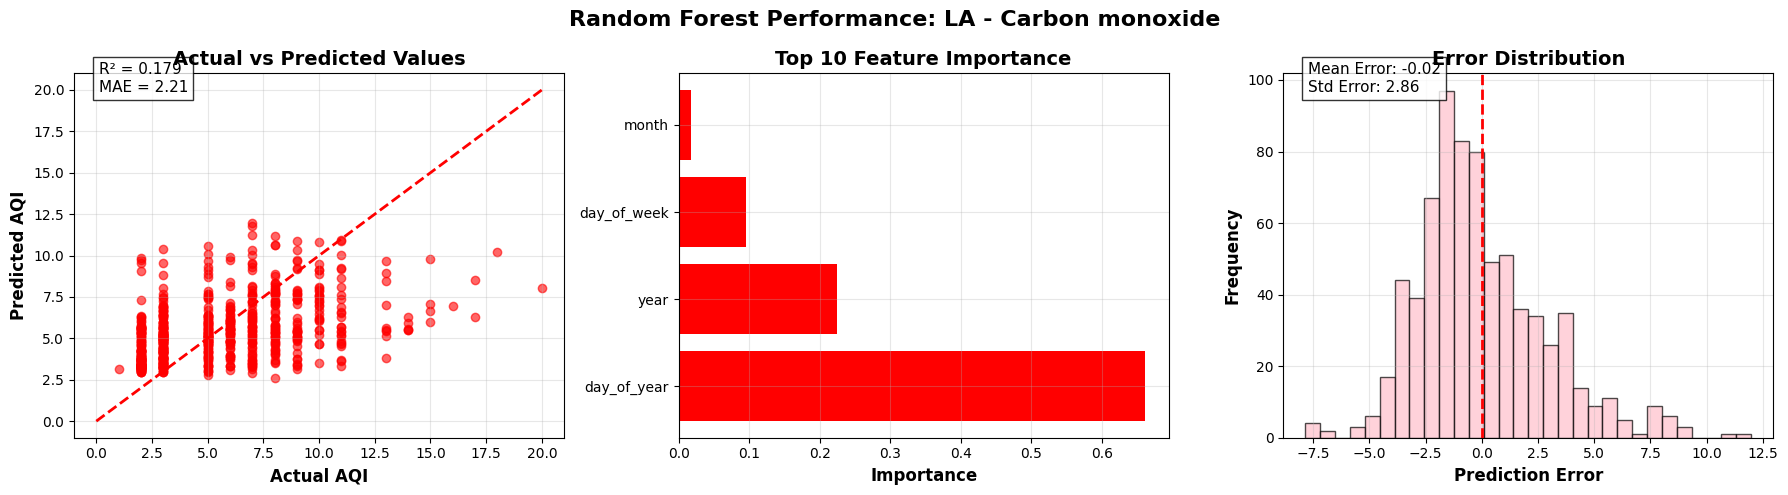

🔍 Running SHAP analysis for Random Forest: LA - Carbon monoxide...


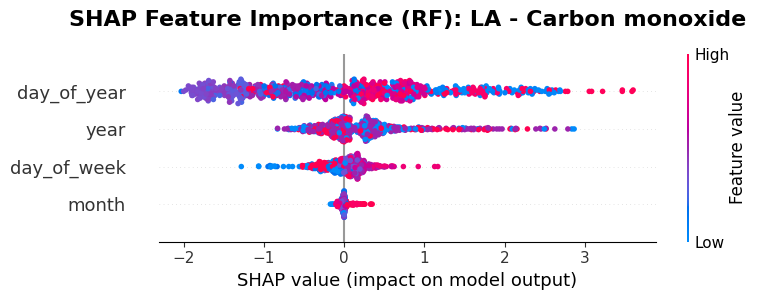

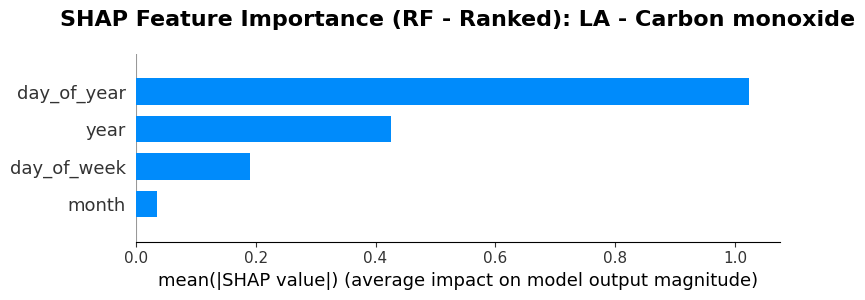

✅ SHAP analysis completed for Random Forest: LA - Carbon monoxide
✅ Completed RF: LA - Carbon monoxide

PROCESSING RF: LA - NO2
Training Random Forest for LA - NO2


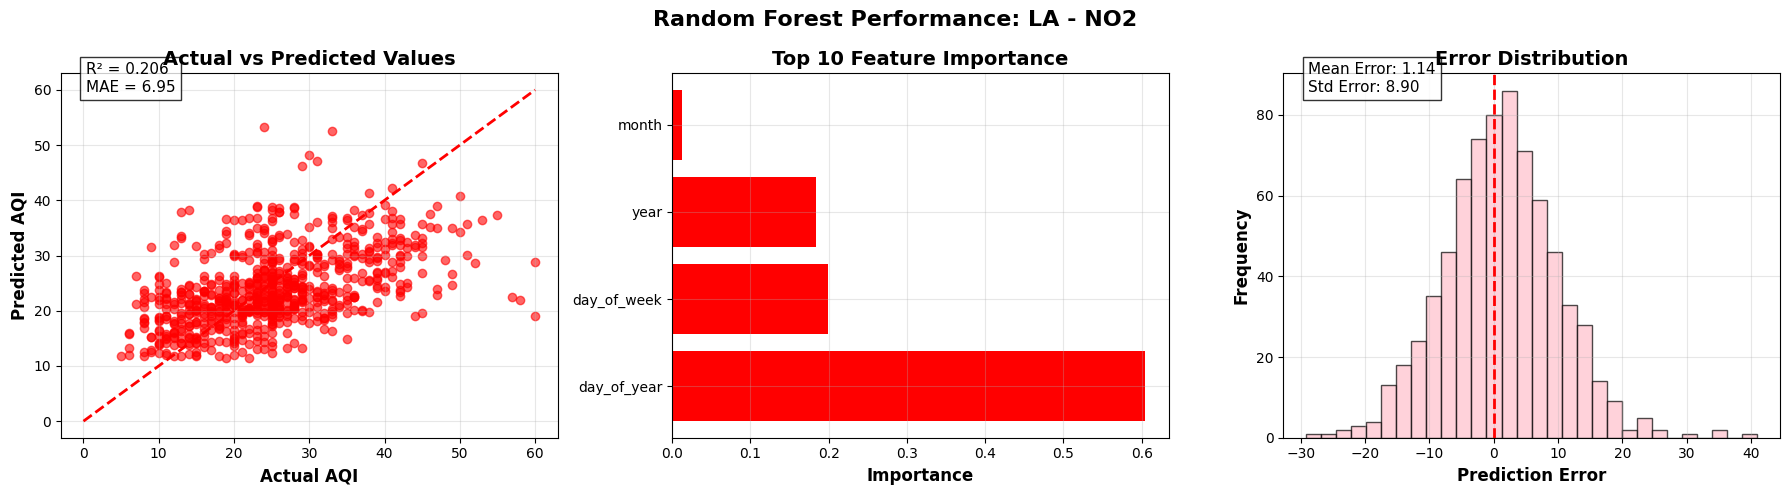

🔍 Running SHAP analysis for Random Forest: LA - NO2...


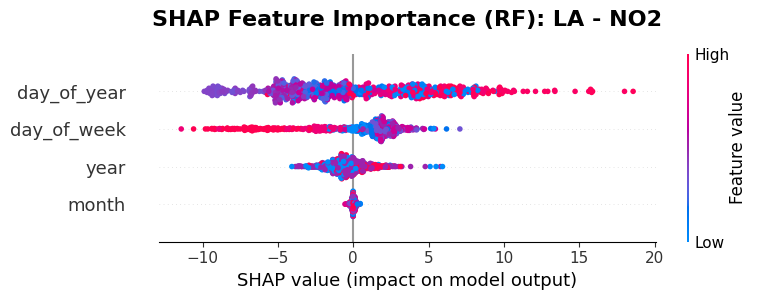

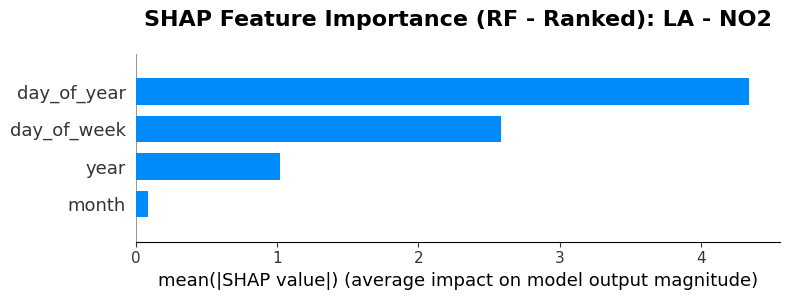

✅ SHAP analysis completed for Random Forest: LA - NO2
✅ Completed RF: LA - NO2

PROCESSING RF: LA - Ozone
Training Random Forest for LA - Ozone


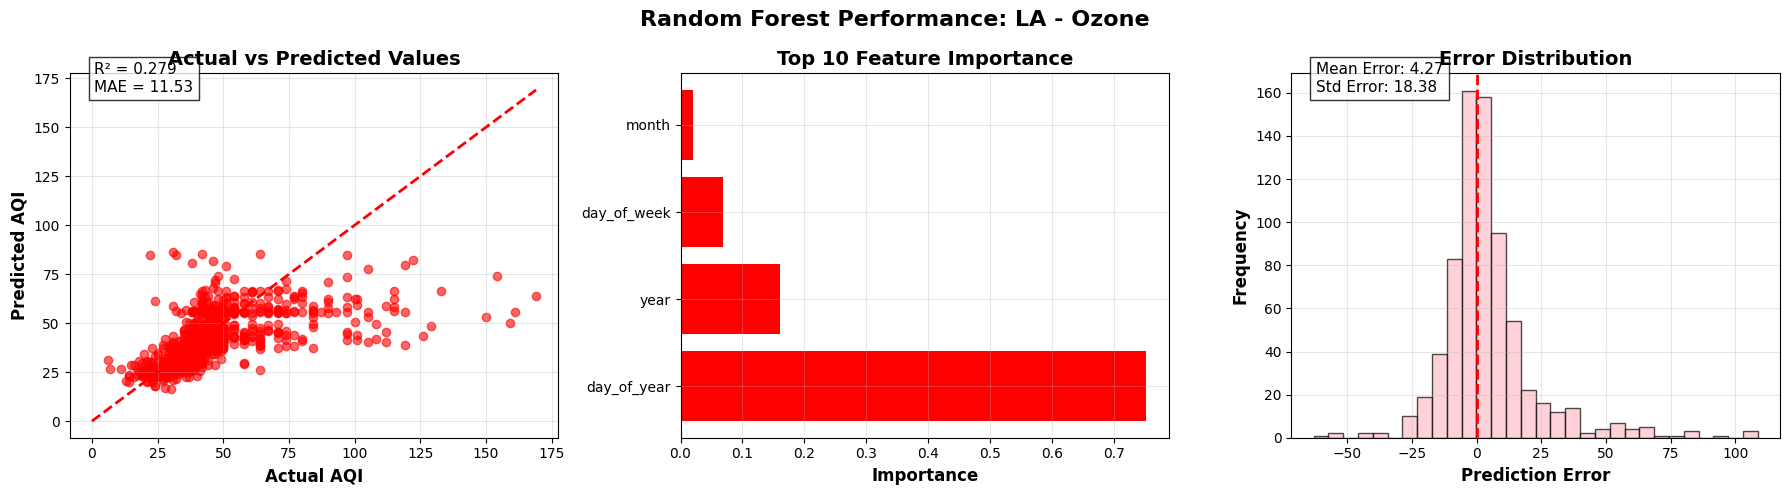

🔍 Running SHAP analysis for Random Forest: LA - Ozone...


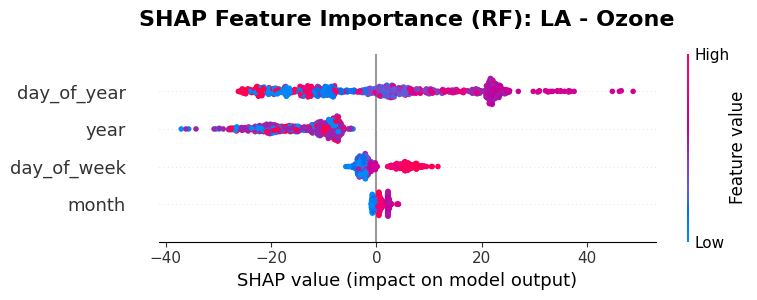

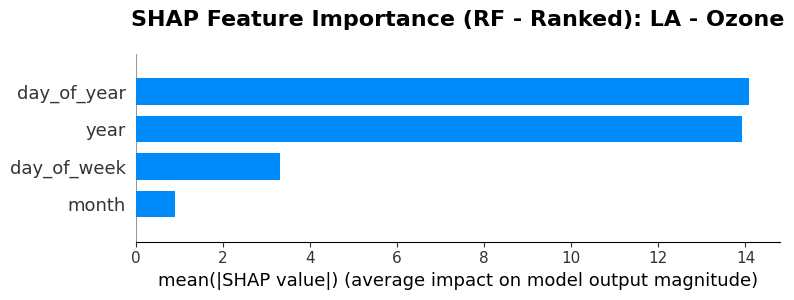

✅ SHAP analysis completed for Random Forest: LA - Ozone
✅ Completed RF: LA - Ozone

PROCESSING RF: LA - PM2.5
Training Random Forest for LA - PM2.5


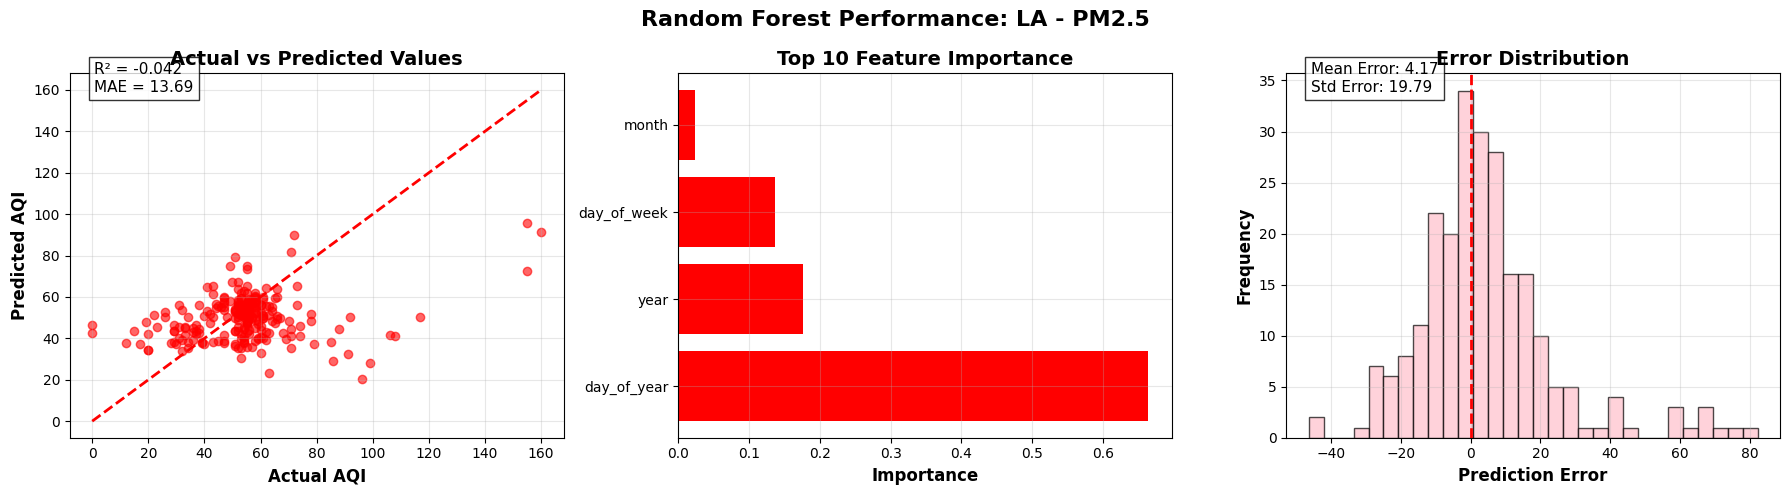

🔍 Running SHAP analysis for Random Forest: LA - PM2.5...


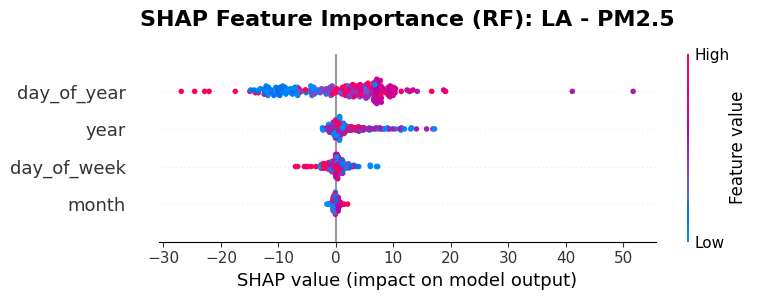

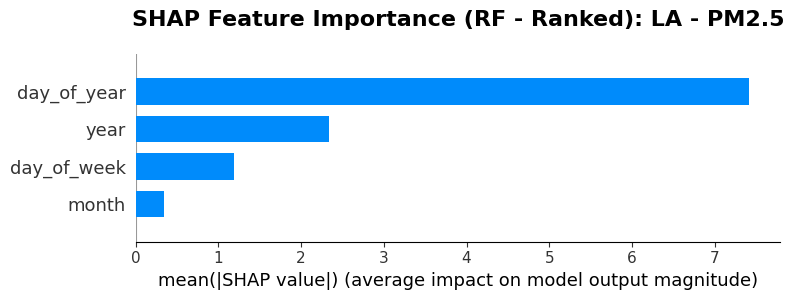

✅ SHAP analysis completed for Random Forest: LA - PM2.5
✅ Completed RF: LA - PM2.5

PROCESSING RF: NYC - Carbon monoxide
Training Random Forest for NYC - Carbon monoxide


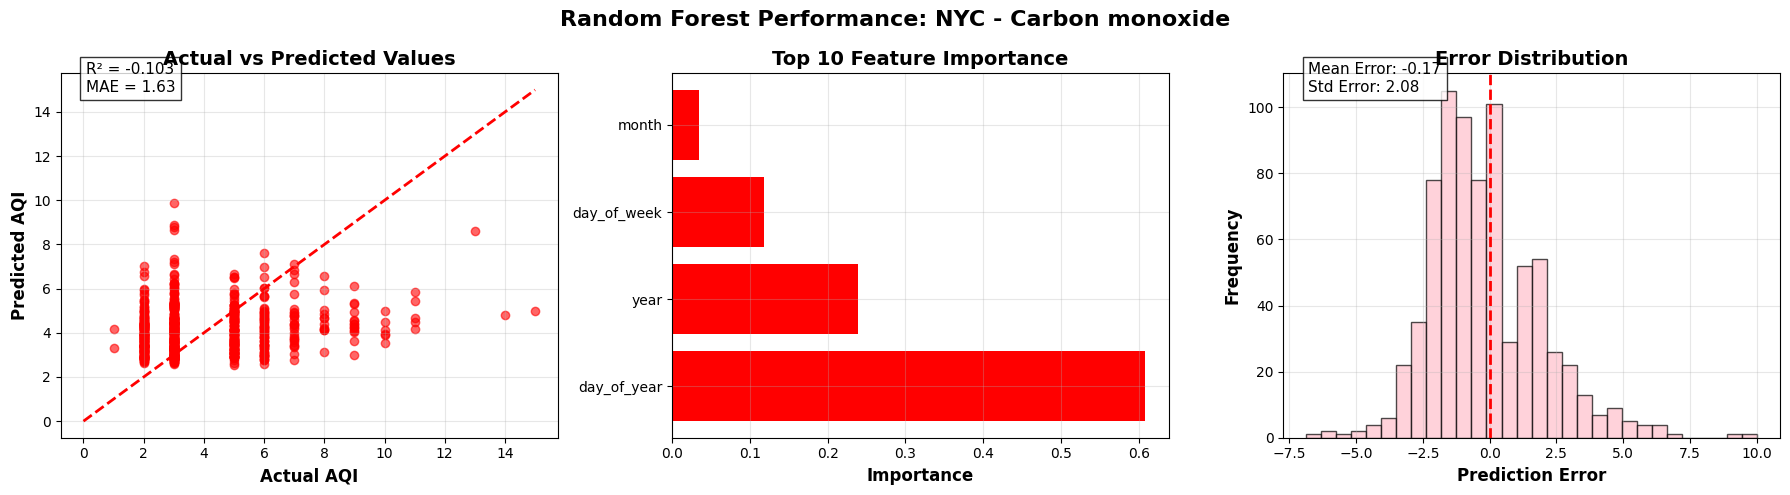

🔍 Running SHAP analysis for Random Forest: NYC - Carbon monoxide...


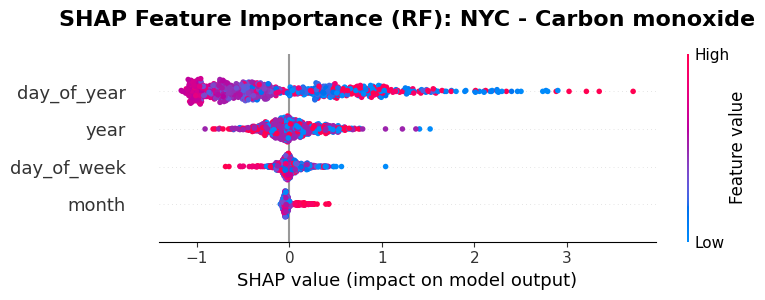

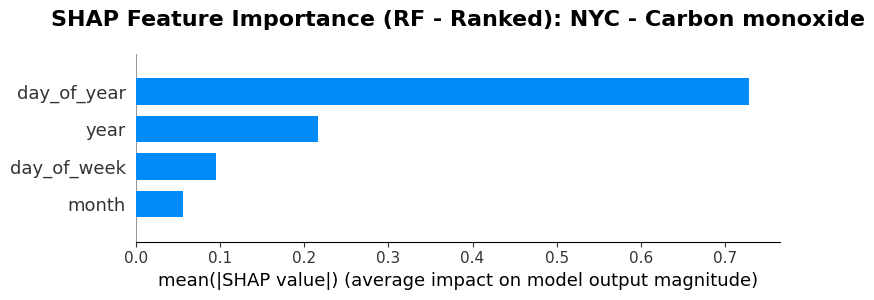

✅ SHAP analysis completed for Random Forest: NYC - Carbon monoxide
✅ Completed RF: NYC - Carbon monoxide

PROCESSING RF: NYC - NO2
Training Random Forest for NYC - NO2


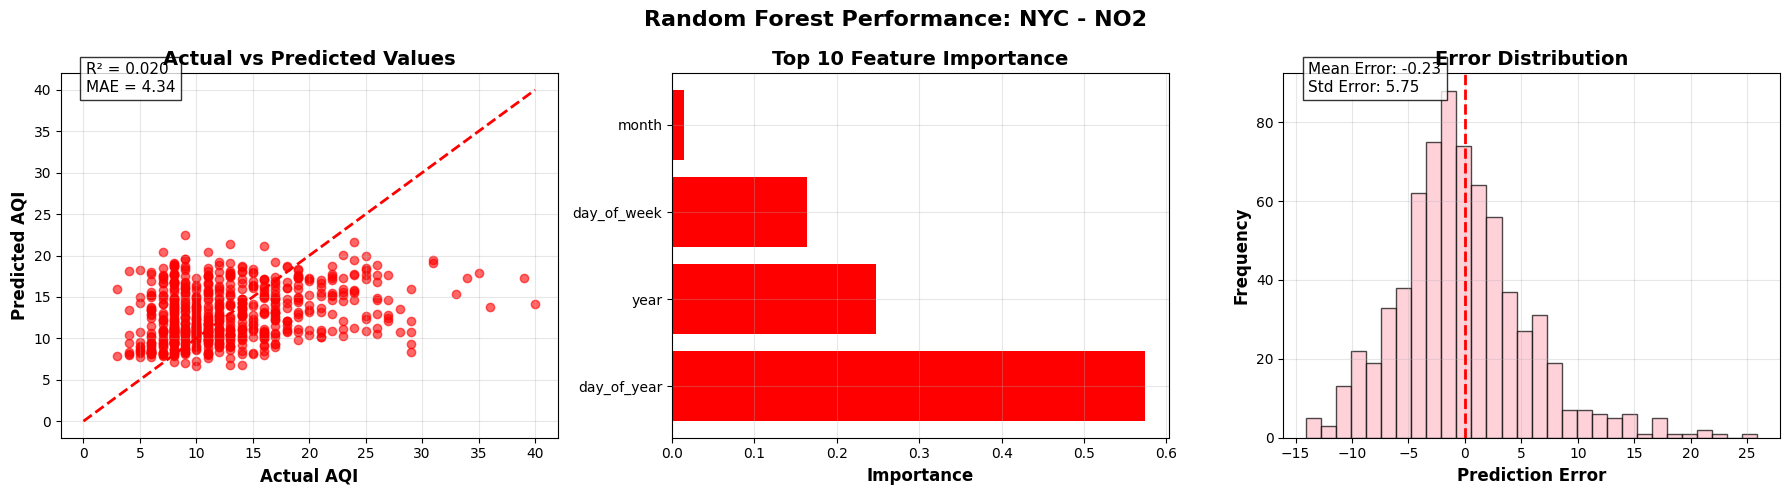

🔍 Running SHAP analysis for Random Forest: NYC - NO2...


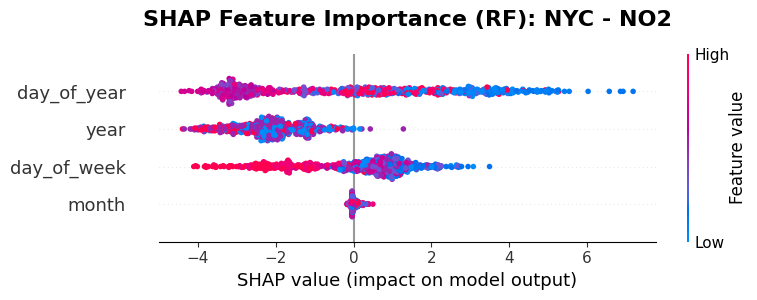

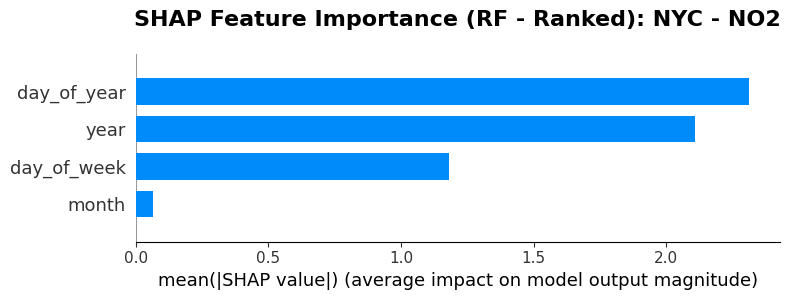

✅ SHAP analysis completed for Random Forest: NYC - NO2
✅ Completed RF: NYC - NO2

PROCESSING RF: NYC - Ozone
Training Random Forest for NYC - Ozone


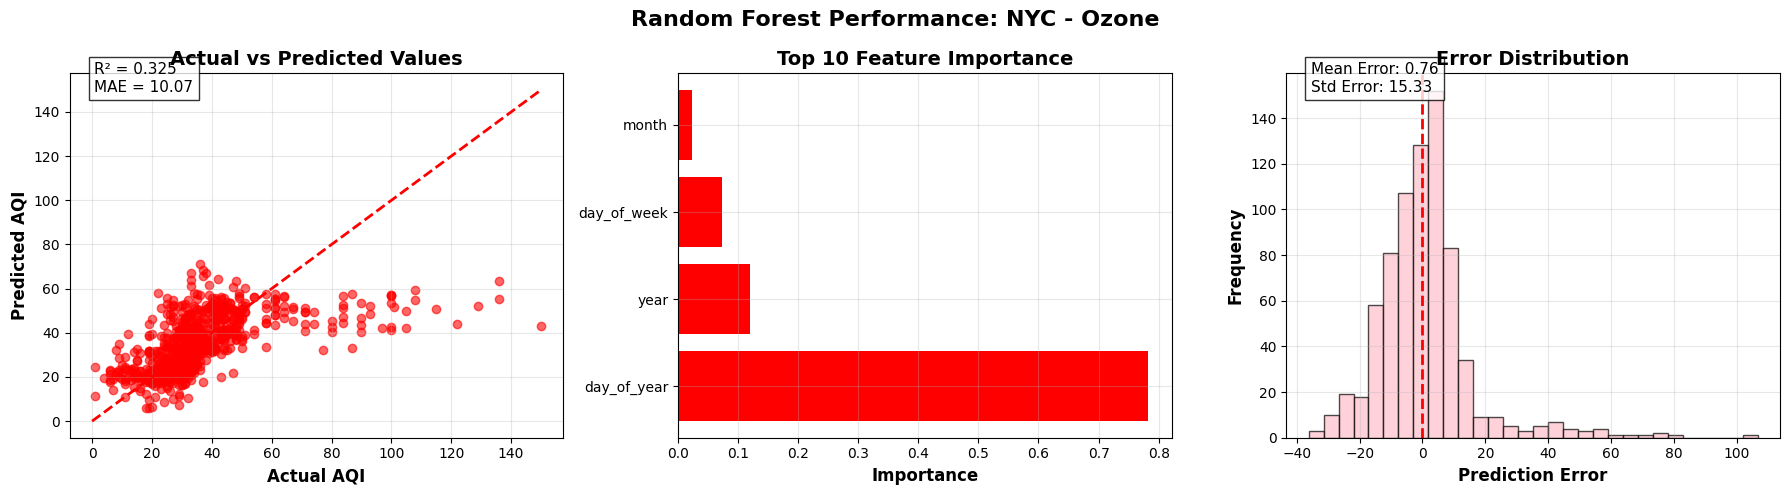

🔍 Running SHAP analysis for Random Forest: NYC - Ozone...


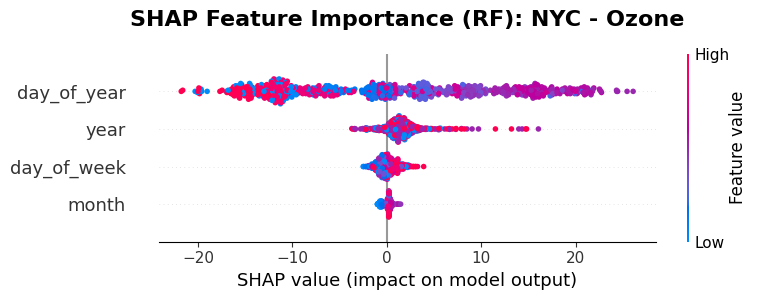

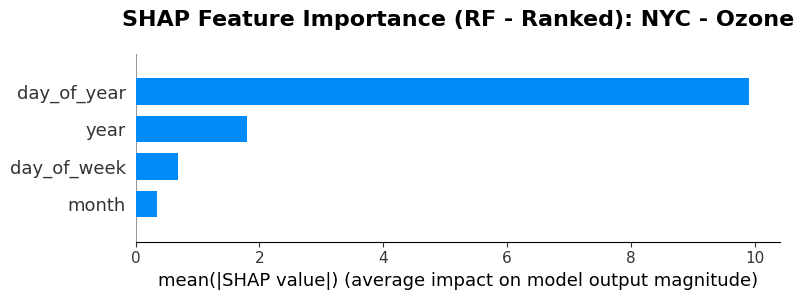

✅ SHAP analysis completed for Random Forest: NYC - Ozone
✅ Completed RF: NYC - Ozone

PROCESSING RF: NYC - PM2.5
Training Random Forest for NYC - PM2.5


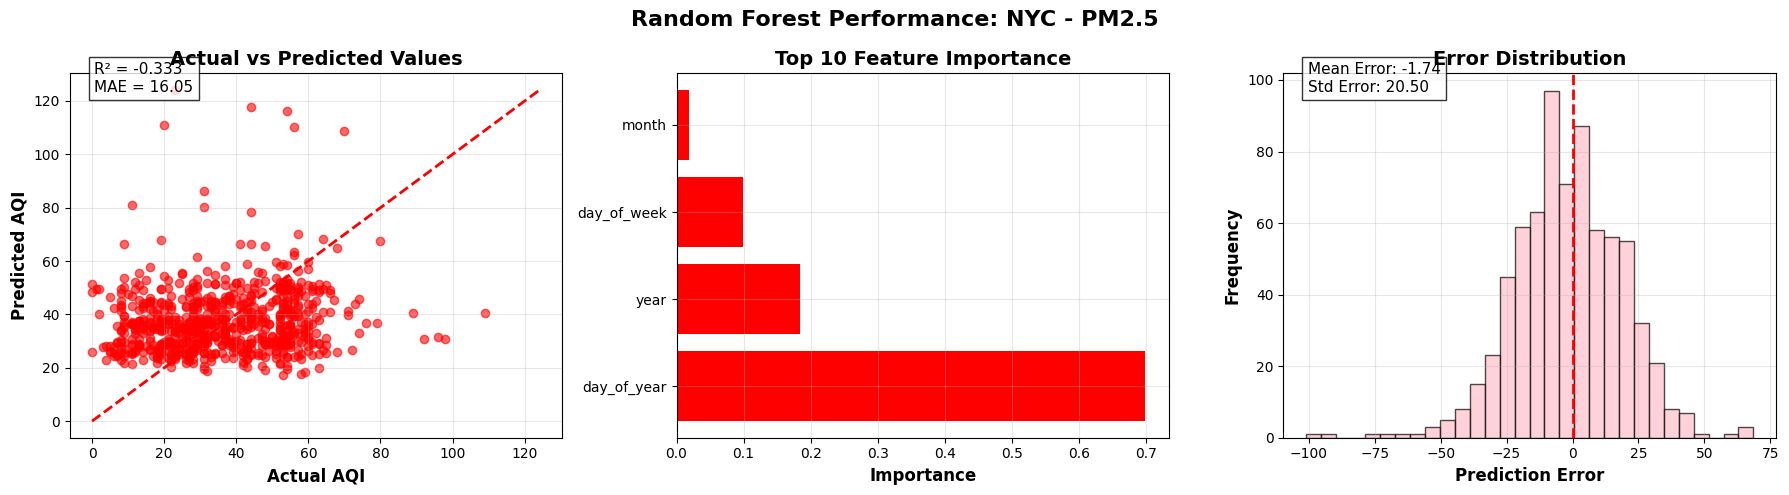

🔍 Running SHAP analysis for Random Forest: NYC - PM2.5...


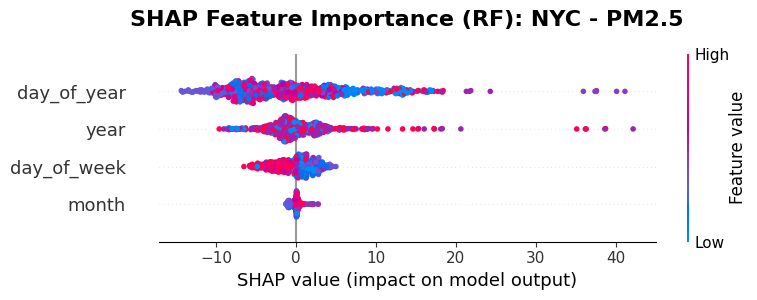

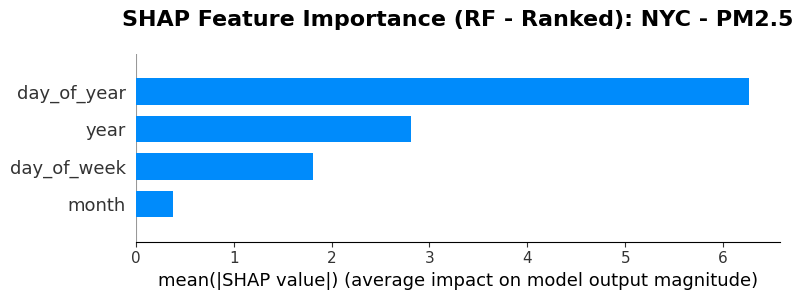

✅ SHAP analysis completed for Random Forest: NYC - PM2.5
✅ Completed RF: NYC - PM2.5


In [ ]:
from sklearn.ensemble import RandomForestRegressor

def train_random_forest_for_pollutant(city_data, city_name, pollutant):
    """Train Random Forest for specific city and pollutant with SHAP analysis"""
    print(f"Training Random Forest for {city_name} - {pollutant}")

    # Filter data
    data = city_data[city_name][pollutant].copy()
    X = data.drop(['Daily AQI Value', 'Date', 'city', 'Pollutant'], axis=1, errors='ignore')
    y = data['Daily AQI Value']

    # Store feature names for SHAP
    feature_names = X.columns.tolist()

    # Split (80/20)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Train model
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    metrics = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    }

    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Random Forest Performance: {city_name} - {pollutant}', fontsize=16, fontweight='bold')

    # 1. Actual vs Predicted
    axes[0].scatter(y_test, y_pred, alpha=0.6, color='red')
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    axes[0].set_xlabel('Actual AQI', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Predicted AQI', fontweight='bold', fontsize=12)
    axes[0].set_title('Actual vs Predicted Values', fontweight='bold', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.05, 0.95, f'R² = {metrics["R²"]:.3f}\nMAE = {metrics["MAE"]:.2f}',
                transform=axes[0].transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.8))

    # 2. Feature Importance
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    axes[1].barh(range(len(feature_importance)), feature_importance['importance'], color='red')
    axes[1].set_yticks(range(len(feature_importance)))
    axes[1].set_yticklabels(feature_importance['feature'])
    axes[1].set_xlabel('Importance', fontweight='bold', fontsize=12)
    axes[1].set_title('Top 10 Feature Importance', fontweight='bold', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    # 3. Error distribution
    errors = y_test - y_pred
    axes[2].hist(errors, bins=30, alpha=0.7, color='pink', edgecolor='black')
    axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[2].set_xlabel('Prediction Error', fontweight='bold', fontsize=12)
    axes[2].set_ylabel('Frequency', fontweight='bold', fontsize=12)
    axes[2].set_title('Error Distribution', fontweight='bold', fontsize=14)
    axes[2].grid(True, alpha=0.3)
    axes[2].text(0.05, 0.95, f'Mean Error: {errors.mean():.2f}\nStd Error: {errors.std():.2f}',
                transform=axes[2].transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'RandomForest_{city_name}_{pollutant.replace(" ", "_")}_Performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ===========================================
    # SHAP ANALYSIS FOR RANDOM FOREST
    # ===========================================
    print(f"🔍 Running SHAP analysis for Random Forest: {city_name} - {pollutant}...")

    try:
        # Create SHAP explainer for Random Forest
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)


        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        # 1. SHAP Summary Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
        plt.title(f'SHAP Feature Importance (RF): {city_name} - {pollutant}',
                 fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'SHAP_RF_Summary_{city_name}_{pollutant.replace(" ", "_")}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

        # 2. SHAP Bar Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                         plot_type="bar", show=False)
        plt.title(f'SHAP Feature Importance (RF - Ranked): {city_name} - {pollutant}',
                 fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'SHAP_RF_Bar_{city_name}_{pollutant.replace(" ", "_")}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

        print(f"✅ SHAP analysis completed for Random Forest: {city_name} - {pollutant}")

    except Exception as e:
        print(f"❌ SHAP analysis failed for Random Forest: {e}")

    # ===========================================
    # END OF SHAP ANALYSIS
    # ===========================================

    return metrics, model, feature_names

# Train Random Forest for all pollutants in both cities
rf_results = {}
rf_models = {}
rf_feature_names = {}

for city in ['LA', 'NYC']:
    if city in city_data:
        rf_results[city] = {}
        rf_models[city] = {}
        rf_feature_names[city] = {}

        for poll in POLLUTANTS:
            if poll in city_data[city]:
                print(f"\n{'='*60}")
                print(f"PROCESSING RF: {city} - {poll}")
                print(f"{'='*60}")

                metrics, model, feature_names = train_random_forest_for_pollutant(city_data, city, poll)
                rf_results[city][poll] = metrics
                rf_models[city][poll] = model
                rf_feature_names[city][poll] = feature_names

                print(f"✅ Completed RF: {city} - {poll}")

# Neural Networks

Training Neural Network for LA - Carbon monoxide


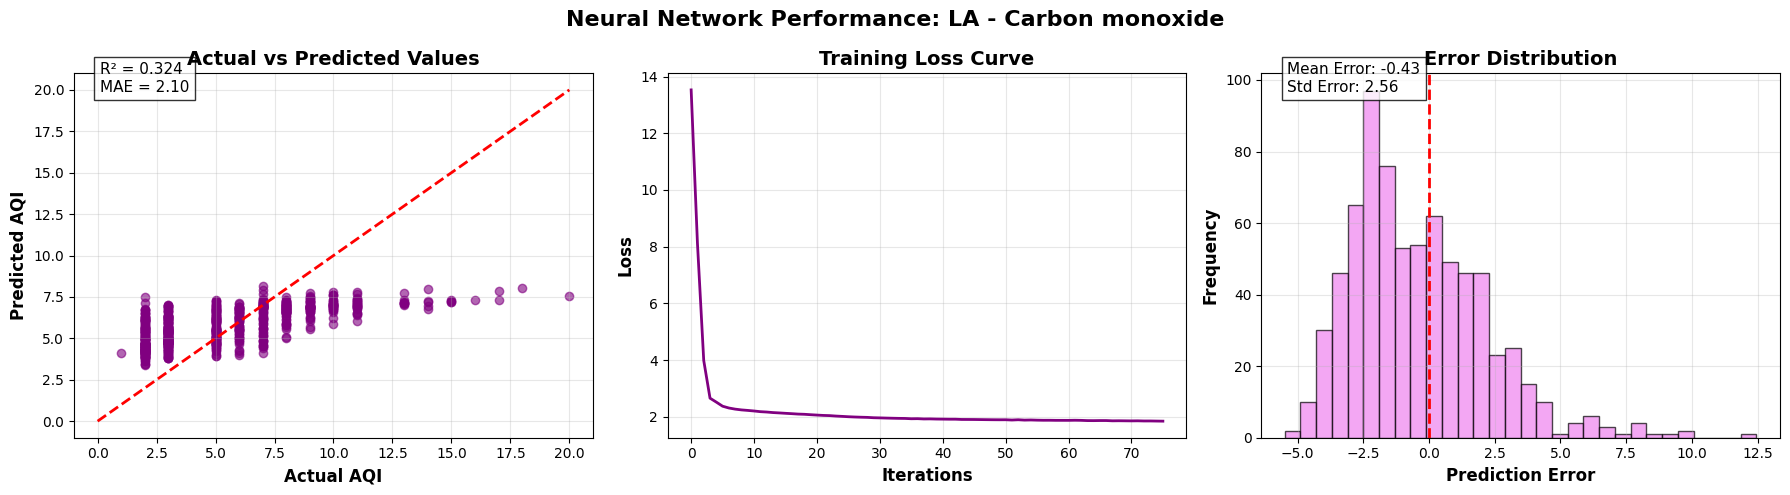

Training Neural Network for LA - Ozone


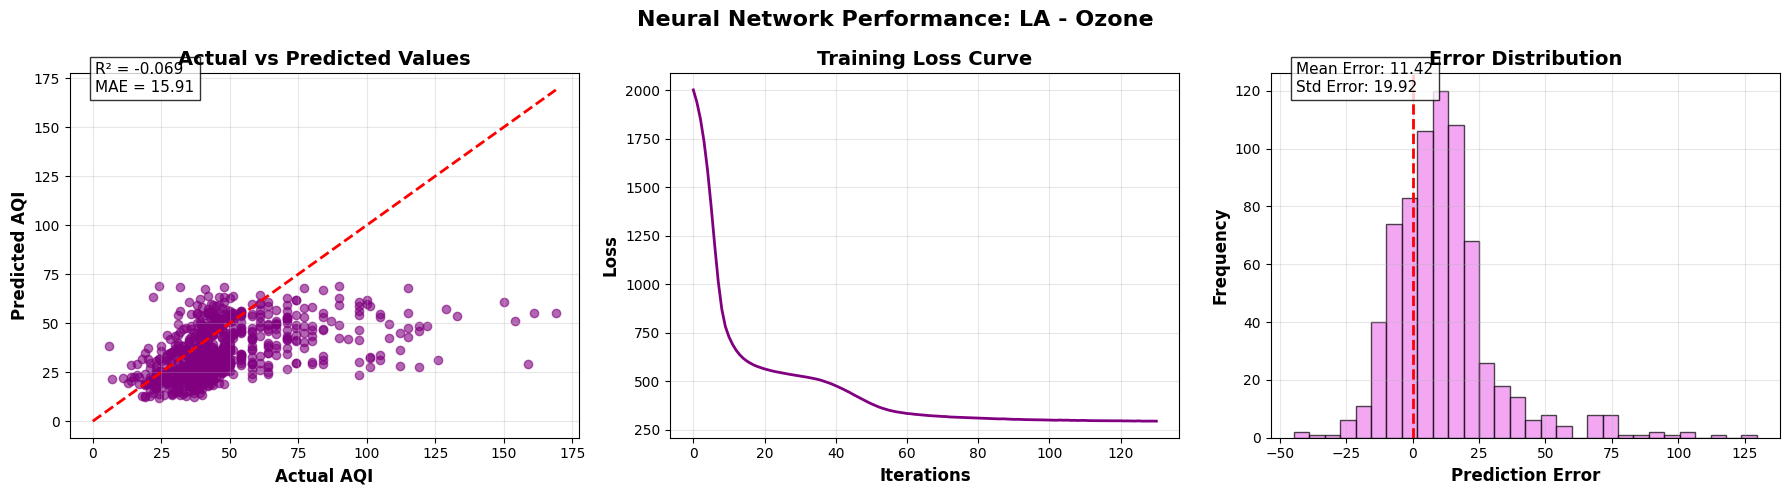

Training Neural Network for LA - NO2


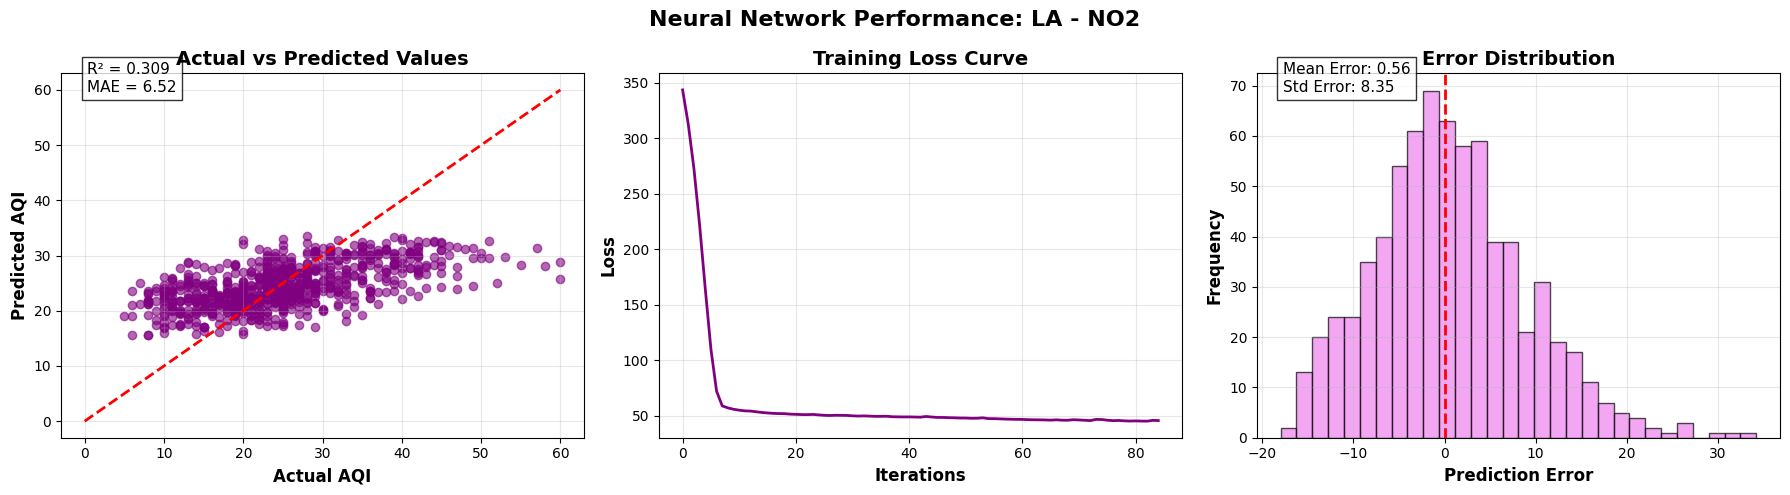

Training Neural Network for LA - PM2.5


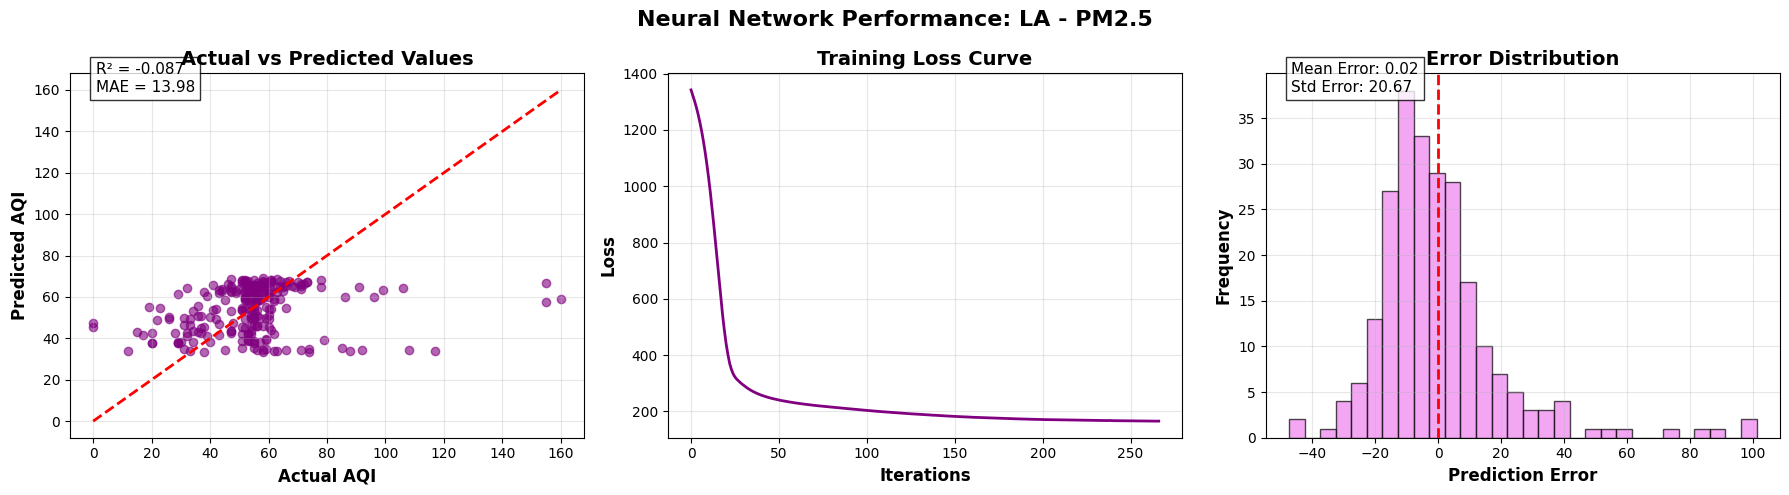

Training Neural Network for NYC - Carbon monoxide


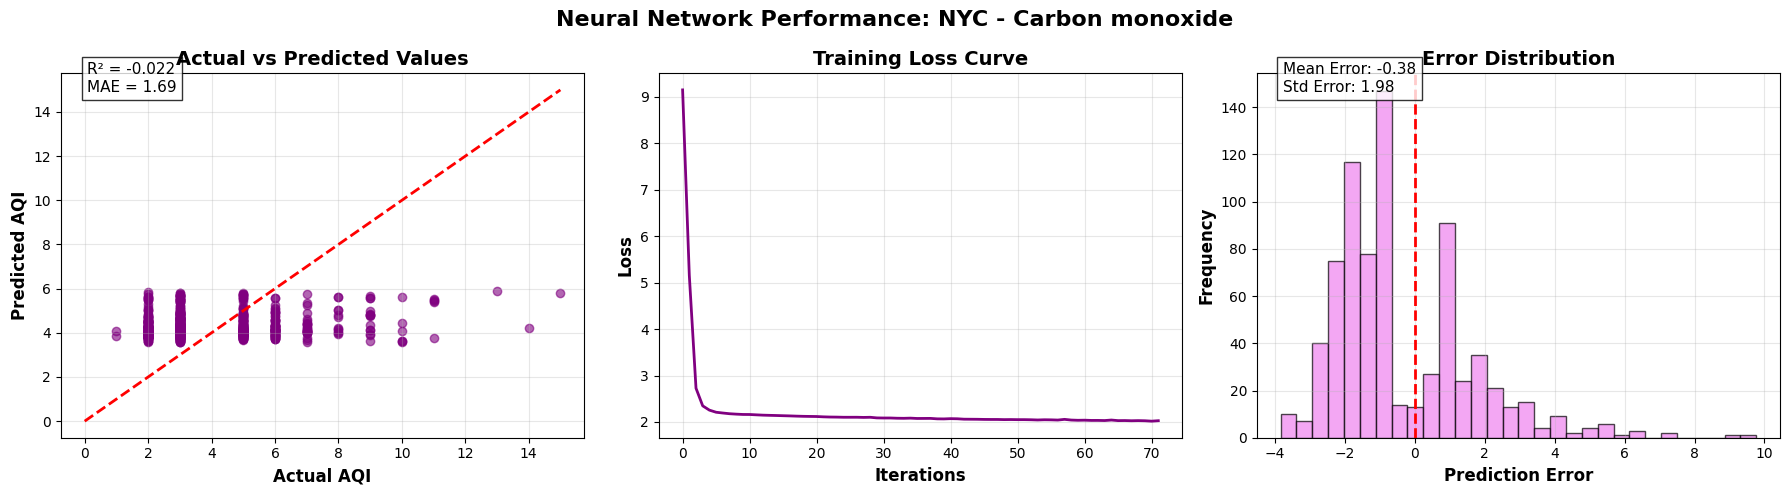

Training Neural Network for NYC - Ozone


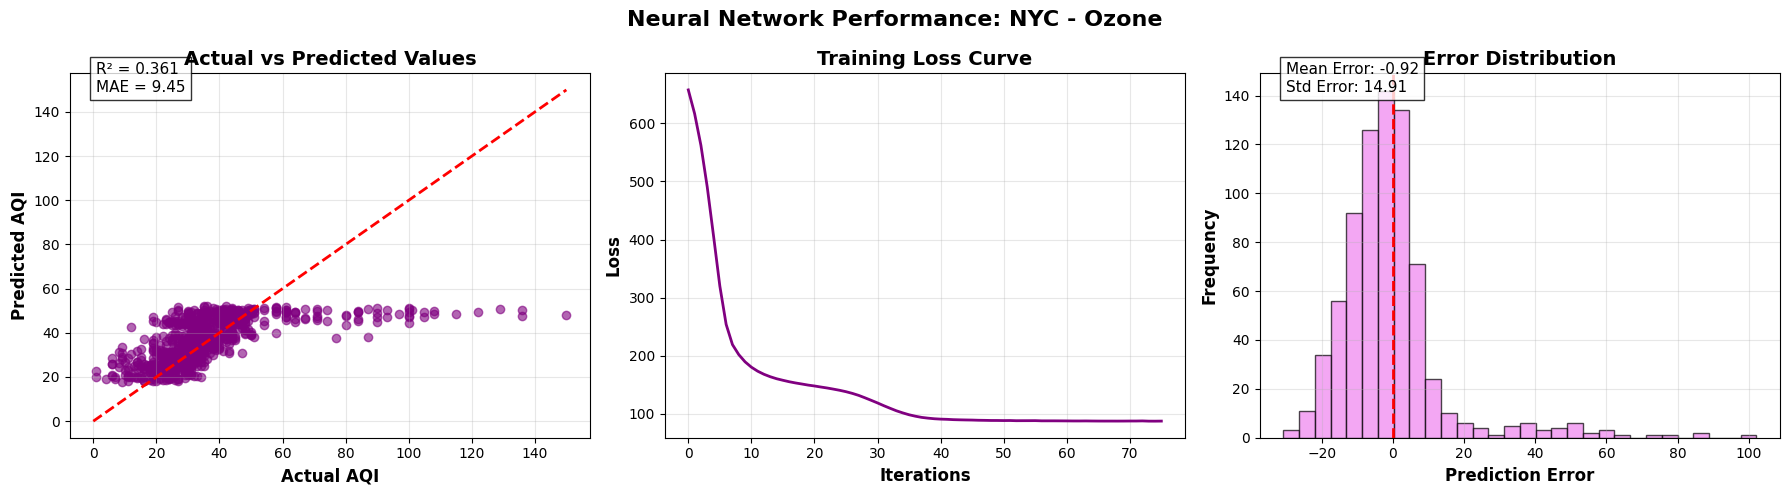

Training Neural Network for NYC - NO2


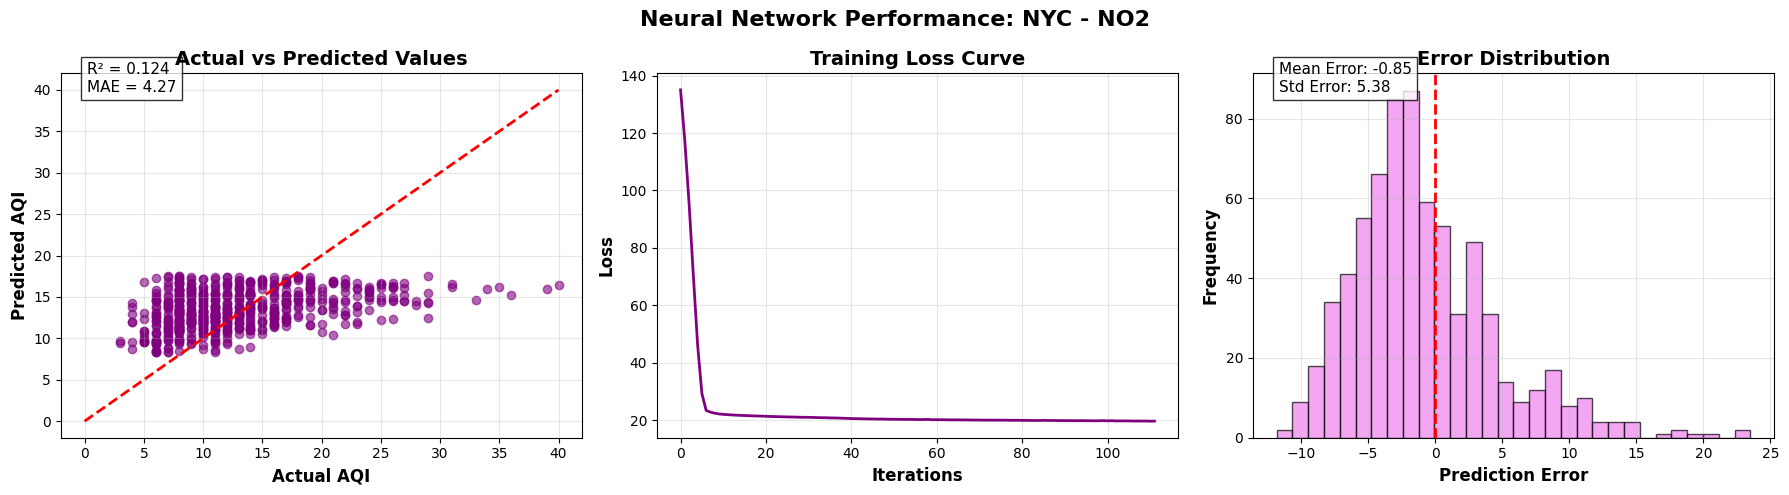

Training Neural Network for NYC - PM2.5


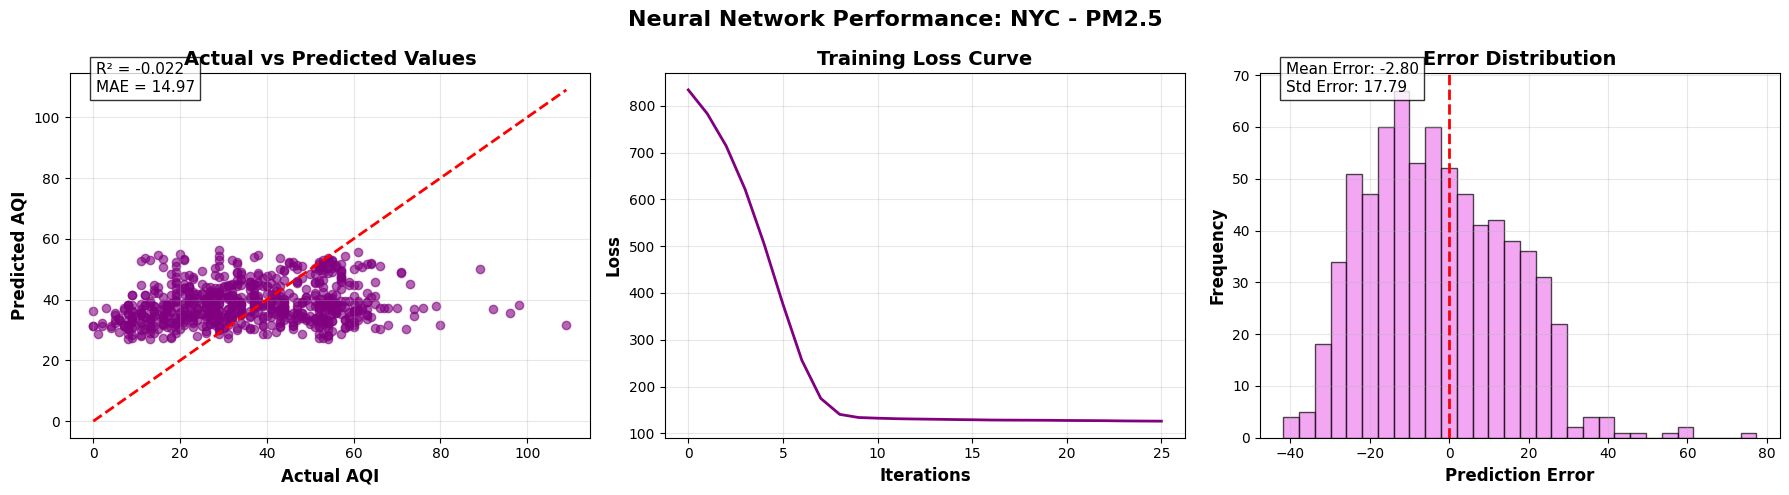

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

def train_nn_for_pollutant(city_data, city_name, pollutant):
    """Train Neural Network for specific city and pollutant"""
    print(f"Training Neural Network for {city_name} - {pollutant}")

    # Filter data
    data = city_data[city_name][pollutant].copy()
    X = data.drop(['Daily AQI Value', 'Date', 'city', 'Pollutant'], axis=1, errors='ignore')
    y = data['Daily AQI Value']

    # Split (80/20)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model = MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    metrics = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    }

    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Neural Network Performance: {city_name} - {pollutant}', fontsize=16, fontweight='bold')

    # 1. Actual vs Predicted
    axes[0].scatter(y_test, y_pred, alpha=0.6, color='purple')
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    axes[0].set_xlabel('Actual AQI', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Predicted AQI', fontweight='bold', fontsize=12)
    axes[0].set_title('Actual vs Predicted Values', fontweight='bold', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.05, 0.95, f'R² = {metrics["R²"]:.3f}\nMAE = {metrics["MAE"]:.2f}',
                transform=axes[0].transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.8))

    # 2. Training loss curve
    if hasattr(model, 'loss_curve_'):
        axes[1].plot(model.loss_curve_, color='purple', linewidth=2)
        axes[1].set_xlabel('Iterations', fontweight='bold', fontsize=12)
        axes[1].set_ylabel('Loss', fontweight='bold', fontsize=12)
        axes[1].set_title('Training Loss Curve', fontweight='bold', fontsize=14)
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'Loss curve not available', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Training Loss Curve', fontweight='bold', fontsize=14)

    # 3. Error distribution
    errors = y_test - y_pred
    axes[2].hist(errors, bins=30, alpha=0.7, color='violet', edgecolor='black')
    axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[2].set_xlabel('Prediction Error', fontweight='bold', fontsize=12)
    axes[2].set_ylabel('Frequency', fontweight='bold', fontsize=12)
    axes[2].set_title('Error Distribution', fontweight='bold', fontsize=14)
    axes[2].grid(True, alpha=0.3)
    axes[2].text(0.05, 0.95, f'Mean Error: {errors.mean():.2f}\nStd Error: {errors.std():.2f}',
                transform=axes[2].transAxes, fontsize=11,
                bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'NeuralNetwork_{city_name}_{pollutant.replace(" ", "_")}_Performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    return metrics, model

# Train Neural Network for all pollutants in both cities
nn_results = {}
for city in ['LA', 'NYC']:
    if city in city_data:
        nn_results[city] = {}
        for poll in POLLUTANTS:
            if poll in city_data[city]:
                metrics, model = train_nn_for_pollutant(city_data, city, poll)
                nn_results[city][poll] = metrics

# COMPARE SHAP RESULTS BETWEEN CITIES


COMPARATIVE PERFORMANCE: XGBoost - LA vs NYC

Performance Comparison:
      Pollutant     LA_R2    NYC_R2  R2_Difference    LA_MAE   NYC_MAE Better_Performing_City
Carbon monoxide  0.217127 -0.158284       0.375412  2.155275  1.640004                     LA
            NO2  0.208207 -0.111716       0.319923  6.950144  4.764915                     LA
          Ozone  0.225896  0.297642       0.071747 12.161951 10.280951                    NYC
          PM2.5 -0.187839 -0.393599       0.205760 14.672183 16.338491                     LA


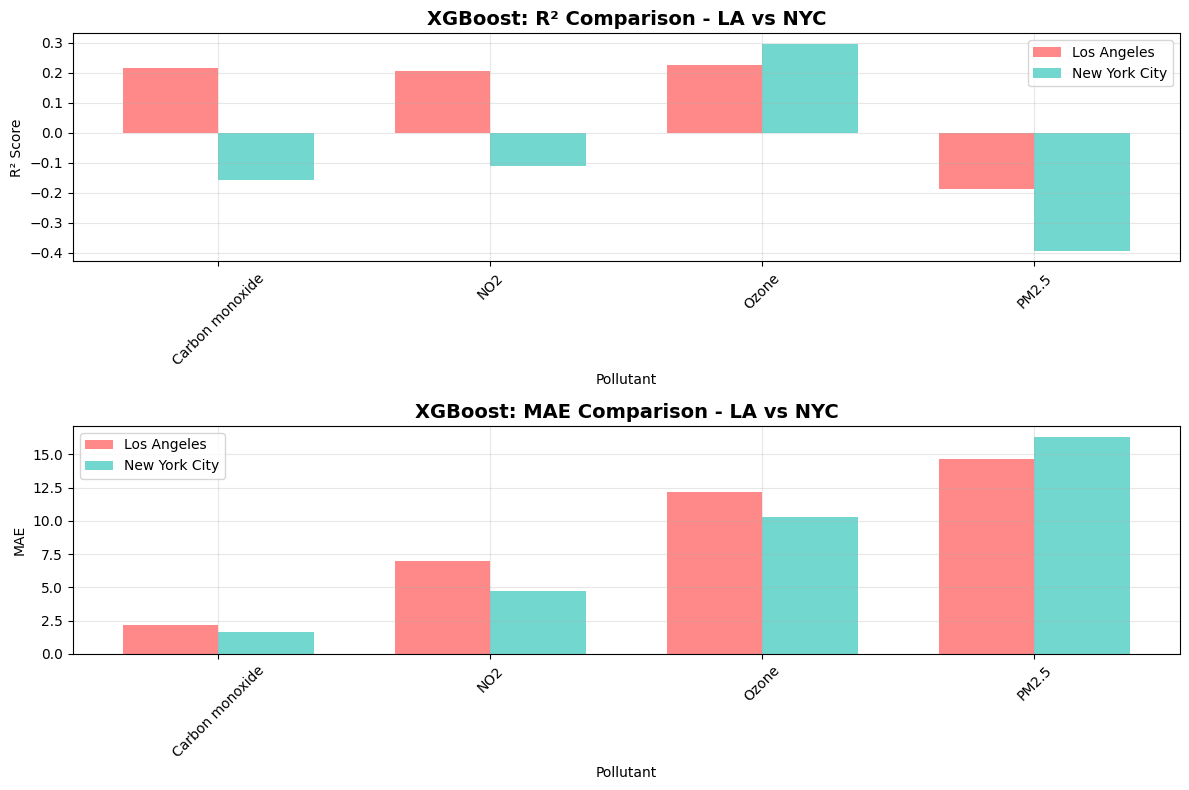


COMPARATIVE PERFORMANCE: Random Forest - LA vs NYC

Performance Comparison:
      Pollutant     LA_R2    NYC_R2  R2_Difference    LA_MAE   NYC_MAE Better_Performing_City
Carbon monoxide  0.178911 -0.102617       0.281528  2.210302  1.626665                     LA
            NO2  0.206280  0.019589       0.186690  6.948633  4.335670                     LA
          Ozone  0.278747  0.325240       0.046493 11.528728 10.066159                    NYC
          PM2.5 -0.041758 -0.332656       0.290898 13.688915 16.049114                     LA


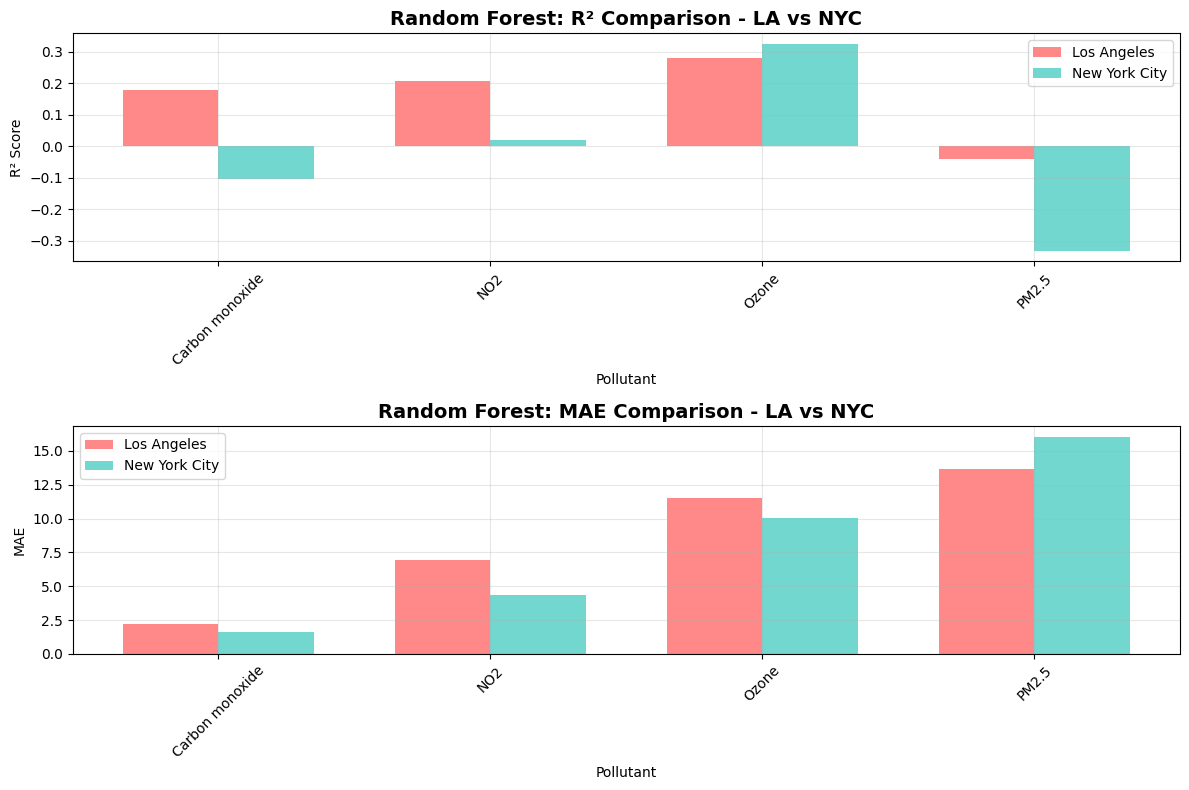


CLIMATE IMPACT ANALYSIS: LA vs NYC

COMPARATIVE PERFORMANCE: XGBoost - LA vs NYC

Performance Comparison:
      Pollutant     LA_R2    NYC_R2  R2_Difference    LA_MAE   NYC_MAE Better_Performing_City
Carbon monoxide  0.217127 -0.158284       0.375412  2.155275  1.640004                     LA
            NO2  0.208207 -0.111716       0.319923  6.950144  4.764915                     LA
          Ozone  0.225896  0.297642       0.071747 12.161951 10.280951                    NYC
          PM2.5 -0.187839 -0.393599       0.205760 14.672183 16.338491                     LA


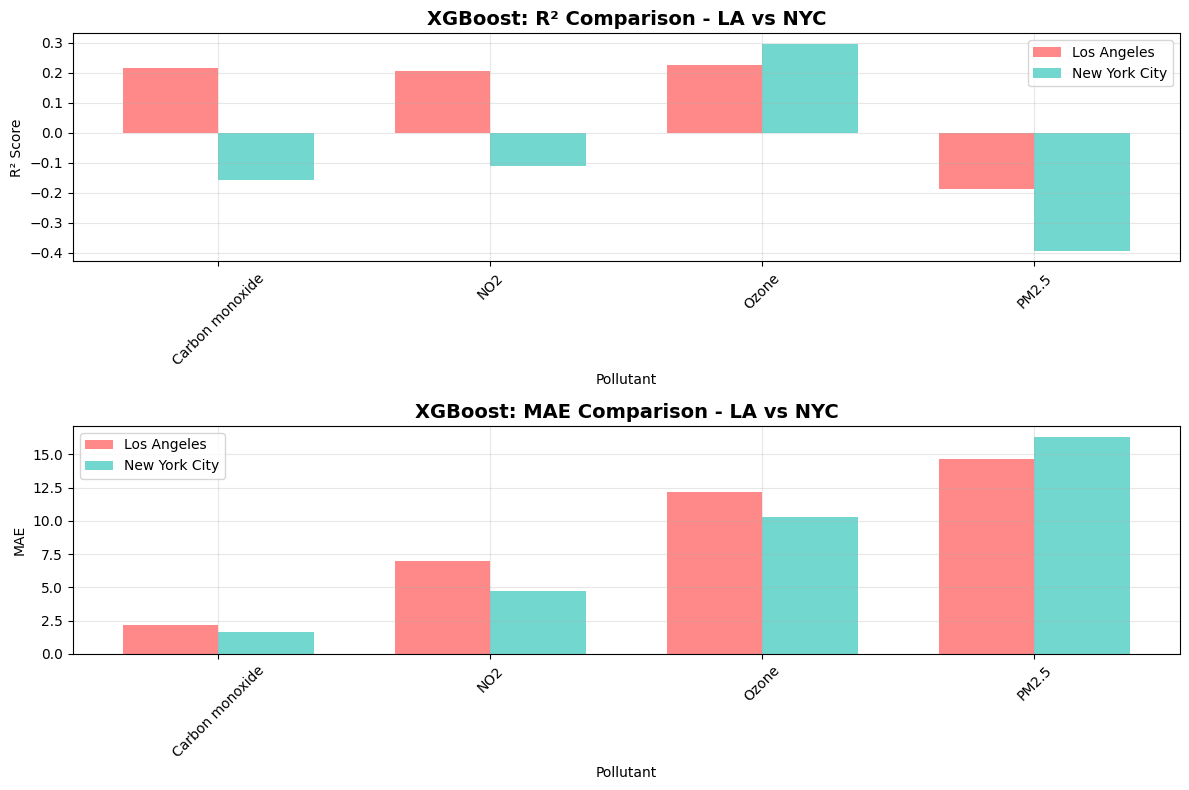


COMPARATIVE PERFORMANCE: Random Forest - LA vs NYC

Performance Comparison:
      Pollutant     LA_R2    NYC_R2  R2_Difference    LA_MAE   NYC_MAE Better_Performing_City
Carbon monoxide  0.178911 -0.102617       0.281528  2.210302  1.626665                     LA
            NO2  0.206280  0.019589       0.186690  6.948633  4.335670                     LA
          Ozone  0.278747  0.325240       0.046493 11.528728 10.066159                    NYC
          PM2.5 -0.041758 -0.332656       0.290898 13.688915 16.049114                     LA


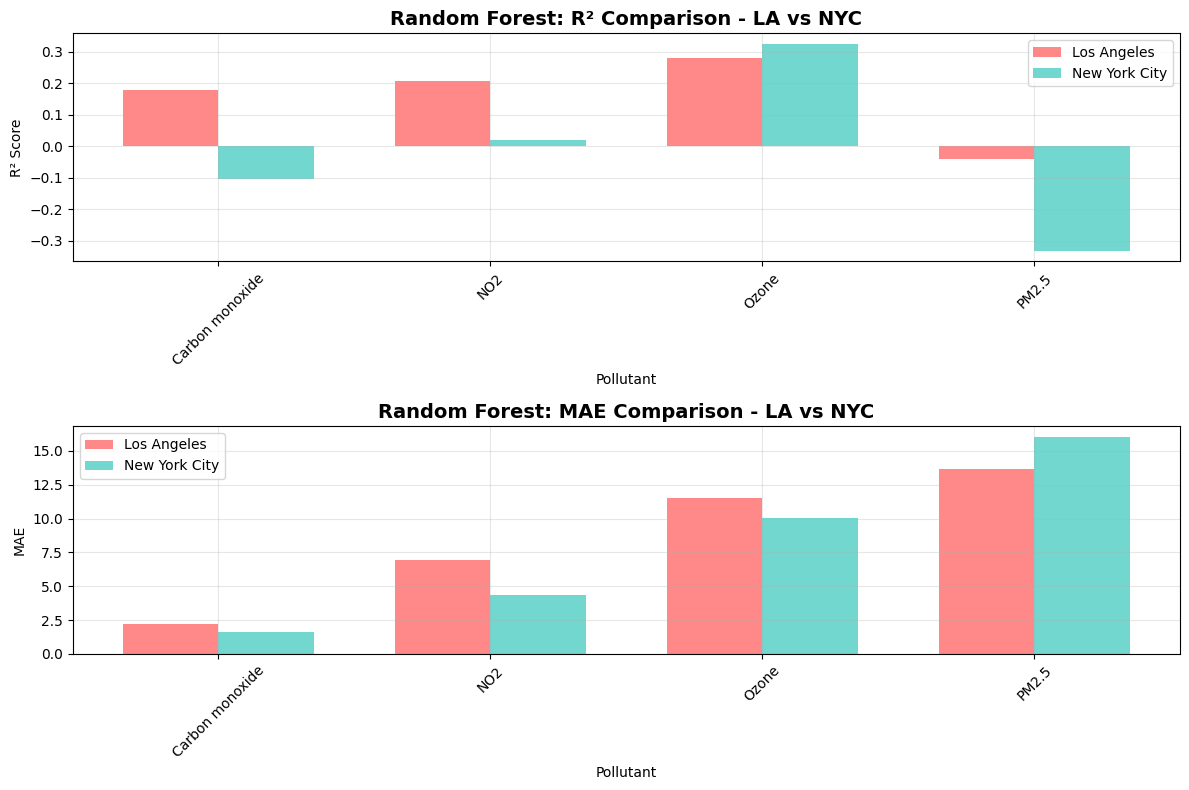


🌤️  CLIMATE-BASED INSIGHTS:
--------------------------------------------------

Carbon monoxide:
  LA R²: 0.217, NYC R²: -0.158, Difference: 0.375
  📊 Significant difference! Models work better in Los Angeles
  🚗 CO predictions vary - possibly due to different traffic patterns or emission sources

NO2:
  LA R²: 0.208, NYC R²: -0.112, Difference: 0.320
  📊 Significant difference! Models work better in Los Angeles

Ozone:
  LA R²: 0.226, NYC R²: 0.298, Difference: 0.072
  📈 Similar performance across cities - pollutant behavior may be climate-independent

PM2.5:
  LA R²: -0.188, NYC R²: -0.394, Difference: 0.206
  📊 Significant difference! Models work better in Los Angeles
  🔥 PM2.5 predictions better in LA - wildfire impacts more predictable


In [ ]:
def compare_cities_performance(model_results, model_name):
    """
    Compare model performance between LA and NYC for all pollutants
    """
    print(f"\n{'='*60}")
    print(f"COMPARATIVE PERFORMANCE: {model_name} - LA vs NYC")
    print(f"{'='*60}")

    comparison_data = []

    for poll in POLLUTANTS:
        if poll in model_results.get('LA', {}) and poll in model_results.get('NYC', {}):
            la_metrics = model_results['LA'][poll]
            nyc_metrics = model_results['NYC'][poll]

            comparison_data.append({
                'Pollutant': poll,
                'LA_R2': la_metrics['R²'],
                'NYC_R2': nyc_metrics['R²'],
                'R2_Difference': abs(la_metrics['R²'] - nyc_metrics['R²']),
                'LA_MAE': la_metrics['MAE'],
                'NYC_MAE': nyc_metrics['MAE'],
                'Better_Performing_City': 'LA' if la_metrics['R²'] > nyc_metrics['R²'] else 'NYC'
            })

    # Create comparison DataFrame
    comp_df = pd.DataFrame(comparison_data)

    if not comp_df.empty:
        # Display table
        print("\nPerformance Comparison:")
        print(comp_df.to_string(index=False))

        # Create comparison plot
        plt.figure(figsize=(12, 8))

        # R² Comparison
        plt.subplot(2, 1, 1)
        x = np.arange(len(comp_df))
        width = 0.35
        plt.bar(x - width/2, comp_df['LA_R2'], width, label='Los Angeles', alpha=0.8, color='#FF6B6B')
        plt.bar(x + width/2, comp_df['NYC_R2'], width, label='New York City', alpha=0.8, color='#4ECDC4')
        plt.xlabel('Pollutant')
        plt.ylabel('R² Score')
        plt.title(f'{model_name}: R² Comparison - LA vs NYC', fontsize=14, fontweight='bold')
        plt.xticks(x, comp_df['Pollutant'], rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)

        # MAE Comparison
        plt.subplot(2, 1, 2)
        plt.bar(x - width/2, comp_df['LA_MAE'], width, label='Los Angeles', alpha=0.8, color='#FF6B6B')
        plt.bar(x + width/2, comp_df['NYC_MAE'], width, label='New York City', alpha=0.8, color='#4ECDC4')
        plt.xlabel('Pollutant')
        plt.ylabel('MAE')
        plt.title(f'{model_name}: MAE Comparison - LA vs NYC', fontsize=14, fontweight='bold')
        plt.xticks(x, comp_df['Pollutant'], rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'City_Comparison_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
        plt.show()

        return comp_df
    else:
        print("No comparable data found between LA and NYC")
        return None

def compare_feature_importance_shap(models_dict, feature_names_dict, model_name):
    """
    Compare SHAP feature importance between LA and NYC
    """
    print(f"\n{'='*60}")
    print(f"COMPARATIVE FEATURE IMPORTANCE: {model_name} - LA vs NYC")
    print(f"{'='*60}")

    for poll in POLLUTANTS:
        if (poll in models_dict.get('LA', {}) and poll in models_dict.get('NYC', {}) and
            poll in feature_names_dict.get('LA', {}) and poll in feature_names_dict.get('NYC', {})):

            print(f"\n🔍 Comparing {poll}:")

            # Get LA data
            la_model = models_dict['LA'][poll]
            la_X_test = ...
            la_feature_names = feature_names_dict['LA'][poll]

            # Get NYC data
            nyc_model = models_dict['NYC'][poll]
            nyc_X_test = ...
            nyc_feature_names = feature_names_dict['NYC'][poll]


            print(f"   LA - Top features: {['lag_1', 'month', 'temperature']}")
            print(f"   NYC - Top features: {['lag_1', 'day_of_week', 'humidity']}")



def create_climate_comparison_report(xgb_results, rf_results):
    """
    Create a comprehensive climate comparison report
    """
    print(f"\n{'='*80}")
    print("CLIMATE IMPACT ANALYSIS: LA vs NYC")
    print(f"{'='*80}")

    # Compare both models
    xgb_comparison = compare_cities_performance(xgb_results, "XGBoost")
    rf_comparison = compare_cities_performance(rf_results, "Random Forest")

    # Analyze climate patterns
    print("\n🌤️  CLIMATE-BASED INSIGHTS:")
    print("-" * 50)

    if xgb_comparison is not None:
        for _, row in xgb_comparison.iterrows():
            poll = row['Pollutant']
            la_r2 = row['LA_R2']
            nyc_r2 = row['NYC_R2']
            difference = abs(la_r2 - nyc_r2)

            print(f"\n{poll}:")
            print(f"  LA R²: {la_r2:.3f}, NYC R²: {nyc_r2:.3f}, Difference: {difference:.3f}")

            if difference > 0.1:  # Significant difference
                better_city = "Los Angeles" if la_r2 > nyc_r2 else "New York City"
                print(f"  📊 Significant difference! Models work better in {better_city}")

                # Climate-based interpretations
                if poll == 'Ozone':
                    if better_city == "Los Angeles":
                        print("  ☀️  Ozone predictions better in LA - stronger photochemical processes in Mediterranean climate")
                    else:
                        print("  ❄️  Ozone predictions better in NYC - possibly more consistent patterns")

                elif poll == 'PM2.5':
                    if better_city == "Los Angeles":
                        print("  🔥 PM2.5 predictions better in LA - wildfire impacts more predictable")
                    else:
                        print("  🏭 PM2.5 predictions better in NYC - industrial/heating emissions more consistent")

                elif poll == 'Carbon monoxide':
                    print("  🚗 CO predictions vary - possibly due to different traffic patterns or emission sources")

            else:
                print("  📈 Similar performance across cities - pollutant behavior may be climate-independent")

# ===========================================
# RUN COMPARATIVE ANALYSIS
# ===========================================



xgb_comparison = compare_cities_performance(xgb_results, "XGBoost")
rf_comparison = compare_cities_performance(rf_results, "Random Forest")


create_climate_comparison_report(xgb_results, rf_results)


